## 💾 The data
The data is a modified dataset from the U.S. Environmental Protection Agency ([EPA](https://www.epa.gov/outdoor-air-quality-data/download-daily-data)). 

#### Ozone contains the daily air quality summary statistics by monitor for the state of California for 2024. Each row contains the date and the air quality metrics per collection method and site
- "Date" - the calendar date with which the air quality values are associated
- "Source" - the data source: EPA's Air Quality System (AQS), or Airnow reports
- "Site ID" - the id for the air monitoring site
- "POC" - the id number for the monitor
- "Daily Max 8-hour Ozone Concentration" - the highest 8-hour value of the day for ozone concentration
- "Units" - parts per million by volume (ppm)
- "Daily AQI Value" - the highest air quality index value for the day, telling how clean or polluted the air is (a value of 50 represents good air quality, while a value above 300 is hazardous)
- "Local Site Name" - name of the monitoring site
- "Daily Obs Count" - number of observations reported in that day
- "Percent Complete" - indicates whether all expected samples were collected
- "Method Code" - identifier for the collection method
- "CBSA Code" - identifier for the core base statistical area (CBSA)
- "CBSA Name" - name of the core base statistical area
- "State FIPS Code" - identifier for the state
- "State" - name of the state
- "County FIPS Code" - identifer for the county
- "County" - name of the county
- "Site Latitude" - latitude coordinates of the site
- "Site Longitude" - longitude coordinates of the side

In [287]:
import pandas as pd
ozone = pd.read_csv('data/ozone.csv')
ozone.head()

,Date,Source,Site ID,POC,Daily Max 8-hour Ozone Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,Method Code,CBSA Code,CBSA Name,County FIPS Code,County,Site Latitude,Site Longitude
0,/2024,AQS,60010007,1,0.031,ppm,29.0,Livermore,17,100.0,47.0,41860.0,"San Francisco-Oakland-Hayward, CA",1,Alameda,37.687526,-121.784217
1,01/02/2024,AQS,60010007,1,0.037,ppm,34.0,Livermore,17,100.0,47.0,41860.0,"San Francisco-Oakland-Hayward, CA",1,Alameda,37.687526,-121.784217
2,/2024,AQS,60010007,1,NaN,ppm,30.0,Livermore,17,100.0,47.0,41860.0,"San Francisco-Oakland-Hayward, CA",1,Alameda,37.687526,-121.784217
3,January 04/2024,AQS,60010007,1,0.026,ppm,24.0,Livermore,17,100.0,47.0,41860.0,"San Francisco-Oakland-Hayward, CA",1,Alameda,37.687526,-121.784217
4,January 05/2024,AQS,60010007,1,0.027,ppm,25.0,Livermore,17,100.0,47.0,41860.0,"San Francisco-Oakland-Hayward, CA",1,Alameda,37.687526,-121.784217


# Executive Summary: The Golden State, Grey Skies

This report analyzes California's ozone pollution, revealing the critical patterns for targeted action. My key findings show that air quality is not a statewide issue but a regional and seasonal one.

- Seasonal Peaks: Ozone pollution consistently peaks during the hot summer months.
  
- Inland Hotspots: The highest concentrations are found inland, with San Bernardino, Riverside, and Tulare counties identified as the primary hotspots.
  
- Coastal Relief: In contrast, the geospatial analysis shows that coastal cities experience significantly lower average ozone pollution.
  
- The Weekend Effect: While urban activity plays a role, the "weekend effect" was found to be less significant than the overwhelming impact of geography and season.

These insights suggest that efforts to improve air quality should be focused on these specific inland urban areas, particularly during the summer season.

## Q0: EDA and Data Cleaning process ## 
Here are the main data cleaning challenges in five points:

- **Inconsistent Dates:** The Date column contained multiple formats (e.g., '01/02/2024' vs. 'January 02/2024') and missing entries, requiring a custom, order-preserving method to create a clean timeline for each site.
  
- **Missing Measurements:** Key columns like Daily Max 8-hour Ozone Concentration and Daily AQI Value had thousands of missing values and invalid zeros that needed to be filled using grouped linear interpolation.
  
- **Erroneous Outliers:** The Daily Obs Count column contained obvious data entry errors, such as outlier values of 1000, which had to be removed and imputed.

- **Inconsistent Naming:** The County column used inconsistent abbreviations (e.g., 'LA', 'SF') that required standardization to 'Los Angeles' and 'San Francisco' for accurate analysis.
  
- **Missing Location Data:** Several rural monitoring sites were missing CBSA Name information, which required investigation and the creation of a "Non-CBSA" category to avoid data loss.

## 🧑‍⚖️ Judging criteria

| CATEGORY | WEIGHTING | DETAILS                                                              |
|:---------|:----------|:---------------------------------------------------------------------|
| **Recommendations** | 35%       | <ul><li>Clarity of recommendations - how clear and well presented the recommendation is.</li><li>Quality of recommendations - are appropriate analytical techniques used & are the conclusions valid?</li><li>Number of relevant insights found for the target audience.</li></ul>       |
| **Storytelling**  | 35%       | <ul><li>How well the data and insights are connected to the recommendation.</li><li>How the narrative and whole report connects together.</li><li>Balancing making the report in-depth enough but also concise.</li></ul> |
| **Visualizations** | 20% | <ul><li>Appropriateness of visualization used.</li><li>Clarity of insight from visualization.</li></ul> |
| **Votes** | 10% | <ul><li>Up voting - most upvoted entries get the most points.</li></ul> |

In [288]:
import pandas as pd

# --- Load and Pre-filter ---
df = pd.read_csv('data/ozone.csv')

# Clean column names to prevent errors
df.columns = df.columns.str.strip()

print(f"Original number of rows: {len(df)}")
# Remove all data from row index 54261 onwards
df_filtered = df.iloc[:54259].copy()
print(f"Rows after removing noise: {len(df_filtered)}")

# Display the first few rows to verify
print("\nFiltered data preview:")
print(df_filtered.head())

Original number of rows: 54759
Rows after removing noise: 54259

Filtered data preview:
              Date Source   Site ID  ...   County  Site Latitude Site Longitude
0            /2024    AQS  60010007  ...  Alameda      37.687526    -121.784217
1       01/02/2024    AQS  60010007  ...  Alameda      37.687526    -121.784217
2            /2024    AQS  60010007  ...  Alameda      37.687526    -121.784217
3  January 04/2024    AQS  60010007  ...  Alameda      37.687526    -121.784217
4  January 05/2024    AQS  60010007  ...  Alameda      37.687526    -121.784217

[5 rows x 17 columns]


In [289]:
# This assumes 'df_filtered' from Cell 1 exists.

# --- Parse all valid dates using a strict, two-pass approach ---

# Pass 1: Attempt to parse only the standard 'MM/DD/YYYY' format.
pass1_dates = pd.to_datetime(df_filtered['Date'], format='%m/%d/%Y', errors='coerce')

# Pass 2: Attempt to parse only the custom 'Month DD/YYYY' format.
pass2_dates = pd.to_datetime(df_filtered['Date'], format='%B %d/%Y', errors='coerce')

# Combine the results. Start with the results from the standard format,
# and fill any remaining nulls with the results from the custom format.
df_filtered['Date_Cleaned'] = pass1_dates.fillna(pass2_dates)


# --- Verification ---
print("--- Cell 2: Parsing Complete ---")
print("\nVerification of Date Parsing:")
# Show the original 'Date' column next to the new 'Date_Cleaned' column
print(df_filtered[['Date', 'Date_Cleaned']].head(10))

print("\nInfo on the new date column (note NaT for '/2024' entries):")
df_filtered[['Date_Cleaned']].info()

--- Cell 2: Parsing Complete ---

Verification of Date Parsing:
              Date Date_Cleaned
0            /2024          NaT
1       01/02/2024   2024-01-02
2            /2024          NaT
3  January 04/2024   2024-01-04
4  January 05/2024   2024-01-05
5  January 06/2024   2024-01-06
6       01/07/2024   2024-01-07
7            /2024          NaT
8            /2024          NaT
9  January 10/2024   2024-01-10

Info on the new date column (note NaT for '/2024' entries):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54259 entries, 0 to 54258
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date_Cleaned  45156 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 424.0 KB


In [290]:
# This assumes 'df_filtered' from Cell 2 exists and has the 'Date_Cleaned'
# column with datetime objects and NaT for nulls.

# --- 3. Front-fill missing dates using a method that preserves order ---

# To do this correctly, we define a function that will be applied to each site's data.
def chronological_front_fill(series):
    # This function receives the 'Date_Cleaned' column for a single site.

    # Forward-fill the last known date
    ffilled_dates = series.ffill()

    # Create a counter that increments for each consecutive null.
    # This is the number of days we need to add.
    days_to_add = series.groupby(series.notna().cumsum()).cumcount()

    # Add the incrementing days to the forward-filled date
    return ffilled_dates + pd.to_timedelta(days_to_add, unit='D')

# Apply this function using .transform().
# transform() performs the calculation on each group and returns the results
# in the original order of the dataframe, which is exactly what you want.
df_filtered['Date_Cleaned'] = df_filtered.groupby('Site ID')['Date_Cleaned'].transform(chronological_front_fill)

# --- Verification ---
# Format the column for final viewing
df_frontfilled = df_filtered.copy()
df_frontfilled['Date_Cleaned'] = df_frontfilled['Date_Cleaned'].dt.strftime('%Y-%m-%d')


print("--- Order-Preserving Front-Filling Complete ---")
print("\nVerification Snippet (Original Unsorted Order):")
# This shows the original order is preserved. NaN remains at the start.
print(df_frontfilled[['Date', 'Date_Cleaned']].head(10))

print("\nInfo on the front-filled column:")
df_frontfilled[['Date_Cleaned']].info()

--- Order-Preserving Front-Filling Complete ---

Verification Snippet (Original Unsorted Order):
              Date Date_Cleaned
0            /2024          NaN
1       01/02/2024   2024-01-02
2            /2024   2024-01-03
3  January 04/2024   2024-01-04
4  January 05/2024   2024-01-05
5  January 06/2024   2024-01-06
6       01/07/2024   2024-01-07
7            /2024   2024-01-08
8            /2024   2024-01-09
9  January 10/2024   2024-01-10

Info on the front-filled column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54259 entries, 0 to 54258
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date_Cleaned  54224 non-null  object
dtypes: object(1)
memory usage: 424.0+ KB


In [291]:
# This assumes 'df_frontfilled' from Cell 3 exists.
# We need to work with the datetime objects, so we'll use the unformatted 'df_filtered'
# from the end of Cell 3's logic block.

# --- 4. Back-fill remaining NaN values using a vectorized approach ---

# Define a function for the back-filling logic.
def chronological_back_fill(series):
    # Back-fill the next known date
    bfilled_dates = series.bfill()

    # Create a counter that increments backwards for each consecutive null.
    # This is the number of days we need to subtract.
    days_to_subtract = series.iloc[::-1].groupby(series.iloc[::-1].notna().cumsum()).cumcount().iloc[::-1]

    # Subtract the incrementing days from the back-filled date
    return bfilled_dates - pd.to_timedelta(days_to_subtract, unit='D')

# Apply this function using .transform() to preserve the original order.
# We apply it to the 'Date_Cleaned' column which still contains NaNs from the start of groups.
df_filtered['Date_Cleaned'] = df_filtered.groupby('Site ID')['Date_Cleaned'].transform(chronological_back_fill)


# --- Verification ---
# Create the final cleaned dataframe for verification
df_final_cleaned = df_filtered.copy()
# Format the date column to a string for clear viewing
df_final_cleaned['Date_Cleaned'] = df_final_cleaned['Date_Cleaned'].dt.strftime('%Y-%m-%d')


print("--- Back-Filling Complete ---")
print("\nVerification Snippet (Site 60010007):")
# The first entry should now be correctly filled.
print(df_final_cleaned[df_final_cleaned['Site ID'] == 60010007][['Date', 'Date_Cleaned']].head(10))

# Final check for any remaining nulls (should be 0)
remaining_nan_count = df_final_cleaned['Date_Cleaned'].isnull().sum()
print(f"\nNumber of remaining NaN values: {remaining_nan_count}")

print("\nFinal DataFrame Info:")
df_final_cleaned.info()

--- Back-Filling Complete ---

Verification Snippet (Site 60010007):
              Date Date_Cleaned
0            /2024   2024-01-01
1       01/02/2024   2024-01-02
2            /2024   2024-01-03
3  January 04/2024   2024-01-04
4  January 05/2024   2024-01-05
5  January 06/2024   2024-01-06
6       01/07/2024   2024-01-07
7            /2024   2024-01-08
8            /2024   2024-01-09
9  January 10/2024   2024-01-10

Number of remaining NaN values: 0

Final DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54259 entries, 0 to 54258
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Date                                  54259 non-null  object 
 1   Source                                54259 non-null  object 
 2   Site ID                               54259 non-null  int64  
 3   POC                                   54259 non-null  int64  
 4   Daily

In [292]:
# This assumes 'df_final_cleaned' from Cell 4 exists.

# --- 5. Final check for any remaining null values ---

# .isnull().sum() counts all the True values (i.e., the NaNs).
final_nan_count = df_final_cleaned['Date_Cleaned'].isnull().sum()

print(f"Final count of NaN values in 'Date_Cleaned': {final_nan_count}")

if final_nan_count == 0:
    print("\nSuccess! The 'Date_Cleaned' column is now fully populated.")
else:
    print("\nThere are still some null values that need to be addressed.")

Final count of NaN values in 'Date_Cleaned': 0

Success! The 'Date_Cleaned' column is now fully populated.


In [293]:
# This assumes 'df_final_cleaned' from the previous cell exists.

# --- 6. Save the final, fully cleaned dataframe to a CSV file ---

# Define the output filename.
output_filename = 'fully_cleaned_dates.csv'

# Save the entire dataframe.
# index=False prevents pandas from writing the dataframe index into the file.
df_final_cleaned.to_csv(output_filename, index=False)

print(f"Successfully saved the final, cleaned dataset to '{output_filename}'.")

Successfully saved the final, cleaned dataset to 'fully_cleaned_dates.csv'.


In [294]:
# This assumes 'df_final_cleaned' from the previous cells exists.

# --- 7. Clean the 'Method Code' column ---
print("--- Cleaning 'Method Code' Column ---")

# Define column names for clarity
method_col = 'Method Code'
source_col = 'Source'

# Report nulls BEFORE cleaning
print(f"Missing values in '{method_col}' before cleaning: {df_final_cleaned[method_col].isnull().sum()}")

# Create a mask to identify rows where the source is 'AirNow'
airnow_mask = df_final_cleaned[source_col] == 'AirNow'

# On just those rows, fill any nulls in 'Method Code' with 0
df_final_cleaned.loc[airnow_mask, method_col] = df_final_cleaned.loc[airnow_mask, method_col].fillna(0)

# Report nulls AFTER cleaning
print(f"Missing values in '{method_col}' after cleaning: {df_final_cleaned[method_col].isnull().sum()}")

# --- Verification ---
print("\nFinal DataFrame Info (note the updated non-null count for Method Code):")
df_final_cleaned.info()

--- Cleaning 'Method Code' Column ---
Missing values in 'Method Code' before cleaning: 6421
Missing values in 'Method Code' after cleaning: 0

Final DataFrame Info (note the updated non-null count for Method Code):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54259 entries, 0 to 54258
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Date                                  54259 non-null  object 
 1   Source                                54259 non-null  object 
 2   Site ID                               54259 non-null  int64  
 3   POC                                   54259 non-null  int64  
 4   Daily Max 8-hour Ozone Concentration  51542 non-null  float64
 5   Units                                 54259 non-null  object 
 6   Daily AQI Value                       51545 non-null  float64
 7   Local Site Name                       54259 non-null  object 
 8   D

In [295]:
import numpy as np

# This assumes 'df_final_cleaned' from Cell 7 exists.

# --- 8. Clean 'Daily Max 8-hour Ozone Concentration' Column ---
print("--- Cleaning 'Daily Max 8-hour Ozone Concentration' ---")

# Define column name
ozone_col = 'Daily Max 8-hour Ozone Concentration'

# --- Verification BEFORE cleaning ---
print(f"Missing values before cleaning: {df_final_cleaned[ozone_col].isnull().sum()}")
print(f"Number of 0s before cleaning: {(df_final_cleaned[ozone_col] == 0).sum()}")

# Step 1: Replace all 0 values with NaN to unify the missing/bad data
df_final_cleaned[ozone_col] = df_final_cleaned[ozone_col].replace(0, np.nan)

# Step 2: Apply grouped linear interpolation
# This fills NaNs based on the linear trend between the previous and next valid points.
# We chain .bfill() and .ffill() to handle cases at the start/end of a site's data.
df_final_cleaned[ozone_col] = df_final_cleaned.groupby('Site ID')[ozone_col].transform(
    lambda x: x.interpolate(method='linear').bfill().ffill()
)

# --- Verification AFTER cleaning ---
print("\n--- Cleaning Complete ---")
print(f"Missing values after cleaning: {df_final_cleaned[ozone_col].isnull().sum()}")
print(f"Number of 0s after cleaning: {(df_final_cleaned[ozone_col] == 0).sum()}")

print("\nFinal DataFrame Info:")
df_final_cleaned.info()

--- Cleaning 'Daily Max 8-hour Ozone Concentration' ---
Missing values before cleaning: 2717
Number of 0s before cleaning: 20

--- Cleaning Complete ---
Missing values after cleaning: 0
Number of 0s after cleaning: 0

Final DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54259 entries, 0 to 54258
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Date                                  54259 non-null  object 
 1   Source                                54259 non-null  object 
 2   Site ID                               54259 non-null  int64  
 3   POC                                   54259 non-null  int64  
 4   Daily Max 8-hour Ozone Concentration  54259 non-null  float64
 5   Units                                 54259 non-null  object 
 6   Daily AQI Value                       51545 non-null  float64
 7   Local Site Name                       54259

In [296]:
import numpy as np

# This assumes 'df_final_cleaned' from Cell 8 exists.

# --- 9. Clean 'Daily AQI Value' Column ---
print("--- Cleaning 'Daily AQI Value' Column ---")

# Define column name
aqi_col = 'Daily AQI Value'

# --- Verification BEFORE cleaning ---
print(f"Missing values before cleaning: {df_final_cleaned[aqi_col].isnull().sum()}")
print(f"Number of 0s before cleaning: {(df_final_cleaned[aqi_col] == 0).sum()}")

# Step 1: Replace all 0 values with NaN to unify the missing/bad data
df_final_cleaned[aqi_col] = df_final_cleaned[aqi_col].replace(0, np.nan)

# Step 2: Apply grouped linear interpolation
df_final_cleaned[aqi_col] = df_final_cleaned.groupby('Site ID')[aqi_col].transform(
    lambda x: x.interpolate(method='linear').bfill().ffill()
)

# --- Verification AFTER cleaning ---
print("\n--- Cleaning Complete ---")
print(f"Missing values after cleaning: {df_final_cleaned[aqi_col].isnull().sum()}")
print(f"Number of 0s after cleaning: {(df_final_cleaned[aqi_col] == 0).sum()}")


# --- Final Verification and Save ---
print("\n--- Final Data Cleaning of All Columns Complete ---")
df_final_cleaned.info()

# Save the fully cleaned data to a new CSV file for inspection
output_filename = 'ozone_fully_cleaned_final.csv'
df_final_cleaned.to_csv(output_filename, index=False)
print(f"\nSuccessfully saved the final, cleaned dataset to '{output_filename}'")

--- Cleaning 'Daily AQI Value' Column ---
Missing values before cleaning: 2714
Number of 0s before cleaning: 20

--- Cleaning Complete ---
Missing values after cleaning: 0
Number of 0s after cleaning: 0

--- Final Data Cleaning of All Columns Complete ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54259 entries, 0 to 54258
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Date                                  54259 non-null  object 
 1   Source                                54259 non-null  object 
 2   Site ID                               54259 non-null  int64  
 3   POC                                   54259 non-null  int64  
 4   Daily Max 8-hour Ozone Concentration  54259 non-null  float64
 5   Units                                 54259 non-null  object 
 6   Daily AQI Value                       54259 non-null  float64
 7   Local Site Name            

In [297]:
df_final_cleaned.head()

,Date,Source,Site ID,POC,Daily Max 8-hour Ozone Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,Method Code,CBSA Code,CBSA Name,County FIPS Code,County,Site Latitude,Site Longitude,Date_Cleaned
0,/2024,AQS,60010007,1,0.0310,ppm,29.0,Livermore,17,100.0,47.0,41860.0,"San Francisco-Oakland-Hayward, CA",1,Alameda,37.687526,-121.784217,2024-01-01
1,01/02/2024,AQS,60010007,1,0.0370,ppm,34.0,Livermore,17,100.0,47.0,41860.0,"San Francisco-Oakland-Hayward, CA",1,Alameda,37.687526,-121.784217,2024-01-02
2,/2024,AQS,60010007,1,0.0315,ppm,30.0,Livermore,17,100.0,47.0,41860.0,"San Francisco-Oakland-Hayward, CA",1,Alameda,37.687526,-121.784217,2024-01-03
3,January 04/2024,AQS,60010007,1,0.0260,ppm,24.0,Livermore,17,100.0,47.0,41860.0,"San Francisco-Oakland-Hayward, CA",1,Alameda,37.687526,-121.784217,2024-01-04
4,January 05/2024,AQS,60010007,1,0.0270,ppm,25.0,Livermore,17,100.0,47.0,41860.0,"San Francisco-Oakland-Hayward, CA",1,Alameda,37.687526,-121.784217,2024-01-05


In [298]:
import numpy as np

# This assumes 'df_final_cleaned' from the previous cell exists.

# --- 10. Clean 'Daily Obs Count' Column ---
print("--- Cleaning 'Daily Obs Count' Column ---")

# Define column name
obs_col = 'Daily Obs Count'

# --- Verification BEFORE cleaning ---
print(f"Number of '1000' values before cleaning: {(df_final_cleaned[obs_col] == 1000).sum()}")

# Step 1: Replace all 1000 values with NaN to prepare for interpolation
df_final_cleaned[obs_col] = df_final_cleaned[obs_col].replace(1000, np.nan)

# Step 2: Apply grouped linear interpolation
# This fills NaNs based on the linear trend between the previous and next valid points.
df_final_cleaned[obs_col] = df_final_cleaned.groupby('Site ID')[obs_col].transform(
    lambda x: x.interpolate(method='linear').bfill().ffill()
)

# --- Verification AFTER cleaning ---
print("\n--- Cleaning Complete ---")
print(f"Number of '1000' values after cleaning: {(df_final_cleaned[obs_col] == 1000).sum()}")

# Verify the fix by checking the summary statistics, especially the 'max' value.
print("\nDescription of the cleaned column:")
print(df_final_cleaned[obs_col].describe())


# --- Final Save ---
# Save the fully cleaned data to a new CSV file for inspection
output_filename = 'ozone_fully_cleaned_final.csv'
df_final_cleaned.to_csv(output_filename, index=False)
print(f"\nSuccessfully saved the final, cleaned dataset to '{output_filename}'")

--- Cleaning 'Daily Obs Count' Column ---
Number of '1000' values before cleaning: 539

--- Cleaning Complete ---
Number of '1000' values after cleaning: 0

Description of the cleaned column:
count    54259.000000
mean        17.704418
std          2.272924
min          1.000000
25%         17.000000
50%         17.000000
75%         17.000000
max         24.000000
Name: Daily Obs Count, dtype: float64

Successfully saved the final, cleaned dataset to 'ozone_fully_cleaned_final.csv'


In [299]:
# --- New Step: Investigate Missing CBSA Data ---
print("\n--- Investigating Sites with Missing CBSA Information ---")

# Define columns to check and display
cbsa_name_col = 'CBSA Name'
columns_to_display = ['Site ID', 'Local Site Name', 'County', 'Site Latitude', 'Site Longitude']

# Create a mask to find all rows where CBSA Name is null
missing_cbsa_mask = df_final_cleaned[cbsa_name_col].isnull()

# Select the unique sites from the rows with missing CBSA info
unique_sites_with_missing_cbsa = df_final_cleaned[missing_cbsa_mask][columns_to_display].drop_duplicates()

# Get the count of unique sites
num_unique_sites = len(unique_sites_with_missing_cbsa)

print(f"\nFound {num_unique_sites} unique sites with missing CBSA information:")

# Display the information for those unique sites
print(unique_sites_with_missing_cbsa.to_string())


--- Investigating Sites with Missing CBSA Information ---

Found 7 unique sites with missing CBSA information:
        Site ID               Local Site Name     County  Site Latitude  Site Longitude
1337   60050002          Jackson-Clinton Road     Amador      38.342606     -120.764426
2412   60090001  San Andreas-Gold Strike Road  Calaveras      38.201850     -120.680277
2757   60111002           Colusa-Sunrise Blvd     Colusa      39.189190     -121.998870
7485   60210003         Willows-Colusa Street      Glenn      39.533870     -122.190834
19301  60430003                   Yosemite NP   Mariposa      37.713250     -119.706200
19665  60430006                    Jerseydale   Mariposa      37.543770     -119.839570
46599  60932001                         Yreka   Siskiyou      41.726892     -122.633579


In [300]:
### NEW STEP: Fill Remaining CBSA Nulls with Placeholders ###
###############################################################

print("\n--- Imputing Placeholders for Missing CBSA Information ---")

# Define columns
cbsa_code_col = 'CBSA Code'
cbsa_name_col = 'CBSA Name'

# Report nulls BEFORE cleaning
print(f"Missing values in '{cbsa_name_col}' before cleaning: {df_final_cleaned[cbsa_name_col].isnull().sum()}")

# Fill remaining nulls with specific placeholders
df_final_cleaned[cbsa_name_col] = df_final_cleaned[cbsa_name_col].fillna("Non-CBSA")
df_final_cleaned[cbsa_code_col] = df_final_cleaned[cbsa_code_col].fillna(0)

# Report nulls AFTER cleaning
print(f"Missing values in '{cbsa_name_col}' after cleaning: {df_final_cleaned[cbsa_name_col].isnull().sum()}")

# --- Final Verification ---
print("\n--- All Data Cleaning is Now Complete ---")
df_final_cleaned.info()

# Save the final dataset
output_filename = 'ozone_fully_cleaned_and_imputed.csv'
df_final_cleaned.to_csv(output_filename, index=False)
print(f"\nSuccessfully saved the final dataset to '{output_filename}'")


--- Imputing Placeholders for Missing CBSA Information ---
Missing values in 'CBSA Name' before cleaning: 2369
Missing values in 'CBSA Name' after cleaning: 0

--- All Data Cleaning is Now Complete ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54259 entries, 0 to 54258
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Date                                  54259 non-null  object 
 1   Source                                54259 non-null  object 
 2   Site ID                               54259 non-null  int64  
 3   POC                                   54259 non-null  int64  
 4   Daily Max 8-hour Ozone Concentration  54259 non-null  float64
 5   Units                                 54259 non-null  object 
 6   Daily AQI Value                       54259 non-null  float64
 7   Local Site Name                       54259 non-null  object 
 8   Daily Obs Cou

In [301]:
### NEW STEP: Get Value Counts for 'County' Column          ###
###############################################################

print("\n--- Value Counts for 'County' Column ---")

# Calculate the number of records for each unique county
county_counts = df_final_cleaned['County'].value_counts()

# Print the result
print(county_counts.to_string())


--- Value Counts for 'County' Column ---
County
Los Angeles        4238
Riverside          3917
San Bernardino     3214
San Diego          3198
Santa Barbara      3171
Kern               2846
Fresno             2522
San Luis Obispo    2156
Ventura            1824
Placer             1798
Sacramento         1729
Alameda            1337
Tulare             1295
Imperial           1200
Santa Clara        1107
Monterey           1091
Contra Costa       1089
Inyo               1002
Shasta              971
Solano              945
El Dorado           755
Orange              722
Stanislaus          721
Madera              720
San Benito          717
Butte               716
Yolo                715
San Joaquin         707
Sutter              579
Tehama              577
Mariposa            576
Mendocino           442
Merced              369
Santa Cruz          366
Siskiyou            365
Tuolumne            363
Glenn               362
Colusa              362
Kings               360
Lake           

In [302]:
df_final_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54259 entries, 0 to 54258
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Date                                  54259 non-null  object 
 1   Source                                54259 non-null  object 
 2   Site ID                               54259 non-null  int64  
 3   POC                                   54259 non-null  int64  
 4   Daily Max 8-hour Ozone Concentration  54259 non-null  float64
 5   Units                                 54259 non-null  object 
 6   Daily AQI Value                       54259 non-null  float64
 7   Local Site Name                       54259 non-null  object 
 8   Daily Obs Count                       54259 non-null  float64
 9   Percent Complete                      54259 non-null  float64
 10  Method Code                           54259 non-null  float64
 11  CBSA Code      

In [303]:
### NEW STEP: Clean 'County' Column Names                   ###
###############################################################

print("\n--- Cleaning 'County' Column ---")

# --- Verification BEFORE cleaning ---
print("\nValue counts for 'County' before cleaning:")
# We'll check the specific values we're about to change
print(df_final_cleaned['County'].value_counts().get('Los Angeles', 'Not found'))
print(df_final_cleaned['County'].value_counts().get('San Francisco', 'Not found'))


# Define the replacements in a dictionary
replacements = {
    'LA': 'Los Angeles',
    'SF': 'San Francisco'
}

# Apply the replacements
df_final_cleaned['County'] = df_final_cleaned['County'].replace(replacements)


# --- Verification AFTER cleaning ---
print("\nValue counts for 'County' after cleaning:")
print(df_final_cleaned['County'].value_counts().get('Los Angeles', 'Not found'))
print(df_final_cleaned['County'].value_counts().get('San Francisco', 'Not found'))

print("\n'County' column has been cleaned.")


--- Cleaning 'County' Column ---

Value counts for 'County' before cleaning:
4238
342

Value counts for 'County' after cleaning:
4275
344

'County' column has been cleaned.


In [304]:
### NEW STEP: Finalize Columns and Save Dataset             ###
###############################################################

print("\n--- Finalizing DataFrame for Export ---")

# 1. Rename the columns as requested
df_final_cleaned = df_final_cleaned.rename(columns={
    'Date_Cleaned': 'Date',
    'Date': 'original_date'
})

# 2. Reorder the columns to move the new 'Date' column to the first position
# Get the full list of columns
cols = df_final_cleaned.columns.tolist()
# Remove the 'Date' column from its current position and insert it at the beginning
cols.insert(0, cols.pop(cols.index('Date')))
# Apply the new column order to the DataFrame
df_final_cleaned = df_final_cleaned[cols]

# 3. Save the final DataFrame to a new CSV file
output_filename = 'ozone_clean_dataset.csv'
df_final_cleaned.to_csv(output_filename, index=False)

print(f"\nSuccessfully saved the final dataset to '{output_filename}'.")

# --- Final Verification ---
print("\nFinal DataFrame Head (showing new column order and names):")
print(df_final_cleaned.head())


--- Finalizing DataFrame for Export ---

Successfully saved the final dataset to 'ozone_clean_dataset.csv'.

Final DataFrame Head (showing new column order and names):
         Date    original_date Source  ...   County  Site Latitude  Site Longitude
0  2024-01-01            /2024    AQS  ...  Alameda      37.687526     -121.784217
1  2024-01-02       01/02/2024    AQS  ...  Alameda      37.687526     -121.784217
2  2024-01-03            /2024    AQS  ...  Alameda      37.687526     -121.784217
3  2024-01-04  January 04/2024    AQS  ...  Alameda      37.687526     -121.784217
4  2024-01-05  January 05/2024    AQS  ...  Alameda      37.687526     -121.784217

[5 rows x 18 columns]


In [305]:
#1. Prepare dataset for time series analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Make a copy to avoid changing the original final DataFrame
df_analysis = df_final_cleaned.copy()

# Convert the 'Date' column to datetime objects
df_analysis['Date'] = pd.to_datetime(df_analysis['Date'])

# Set the 'Date' column as the index for time-series analysis
df_analysis.set_index('Date', inplace=True)

# Set a consistent plot style
plt.style.use('seaborn-v0_8-whitegrid')

print("Analysis DataFrame is ready with 'Date' as the index.")
df_analysis.head()

Analysis DataFrame is ready with 'Date' as the index.


,original_date,Source,Site ID,POC,Daily Max 8-hour Ozone Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,Method Code,CBSA Code,CBSA Name,County FIPS Code,County,Site Latitude,Site Longitude
Date,,,,,,,,,,,,,,,,,
2024-01-01,/2024,AQS,60010007,1,0.0310,ppm,29.0,Livermore,17.0,100.0,47.0,41860.0,"San Francisco-Oakland-Hayward, CA",1,Alameda,37.687526,-121.784217
2024-01-02,01/02/2024,AQS,60010007,1,0.0370,ppm,34.0,Livermore,17.0,100.0,47.0,41860.0,"San Francisco-Oakland-Hayward, CA",1,Alameda,37.687526,-121.784217
2024-01-03,/2024,AQS,60010007,1,0.0315,ppm,30.0,Livermore,17.0,100.0,47.0,41860.0,"San Francisco-Oakland-Hayward, CA",1,Alameda,37.687526,-121.784217
2024-01-04,January 04/2024,AQS,60010007,1,0.0260,ppm,24.0,Livermore,17.0,100.0,47.0,41860.0,"San Francisco-Oakland-Hayward, CA",1,Alameda,37.687526,-121.784217
2024-01-05,January 05/2024,AQS,60010007,1,0.0270,ppm,25.0,Livermore,17.0,100.0,47.0,41860.0,"San Francisco-Oakland-Hayward, CA",1,Alameda,37.687526,-121.784217


## Q1: How does daily maximum 8-hour ozone concentration vary over time and regions?

--- Plotting Overall Ozone Concentration Trend ---


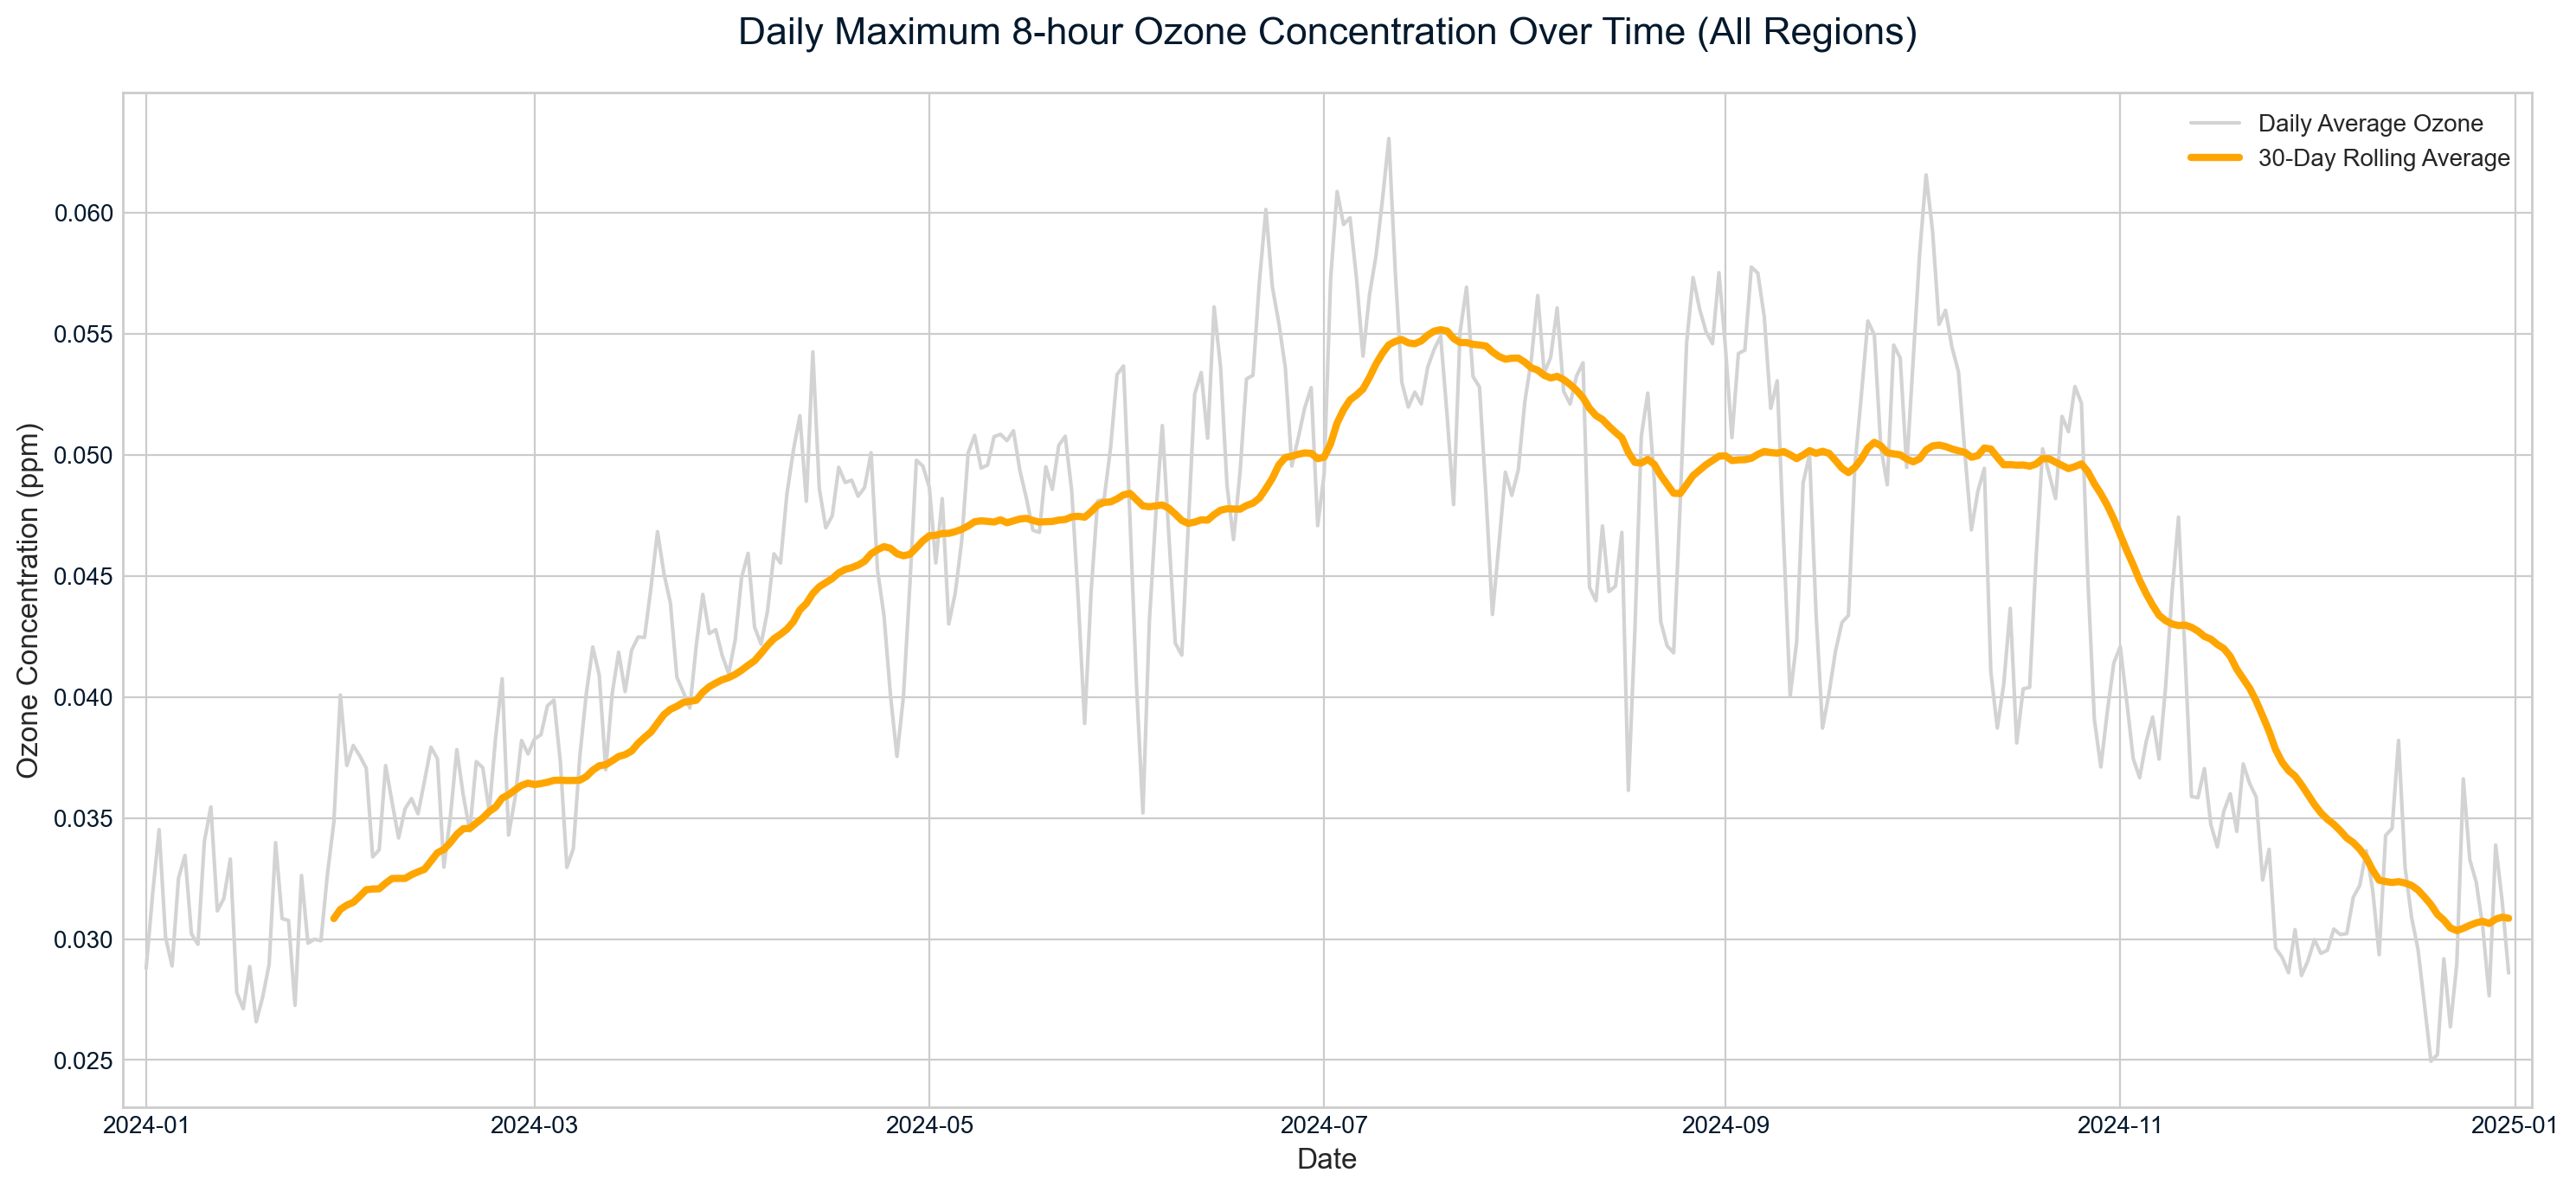

In [306]:
import matplotlib.pyplot as plt

# --- Analyze Overall Temporal Trend ---
print("--- Plotting Overall Ozone Concentration Trend ---")

# Resample to get the mean ozone concentration for each day
daily_average_ozone = df_analysis['Daily Max 8-hour Ozone Concentration'].resample('D').mean()

# Calculate a 30-day rolling average to smooth the trend line
rolling_average_ozone = daily_average_ozone.rolling(window=30).mean()

# --- Plotting ---
fig, ax = plt.subplots(figsize=(15, 7))

# Plot the lines with increased thickness
ax.plot(daily_average_ozone.index, daily_average_ozone, label='Daily Average Ozone', color='lightgray', zorder=1, linewidth=1.5)
ax.plot(rolling_average_ozone.index, rolling_average_ozone, label='30-Day Rolling Average', color='orange', linewidth=3, zorder=2)

# --- Formatting ---
ax.set_title('Daily Maximum 8-hour Ozone Concentration Over Time (All Regions)', fontsize=16, pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Ozone Concentration (ppm)', fontsize=12)

ax.legend()
ax.margins(x=0.01)

plt.tight_layout()
plt.show()

\n--- Identifying Top 10 Counties with Highest Average Ozone ---


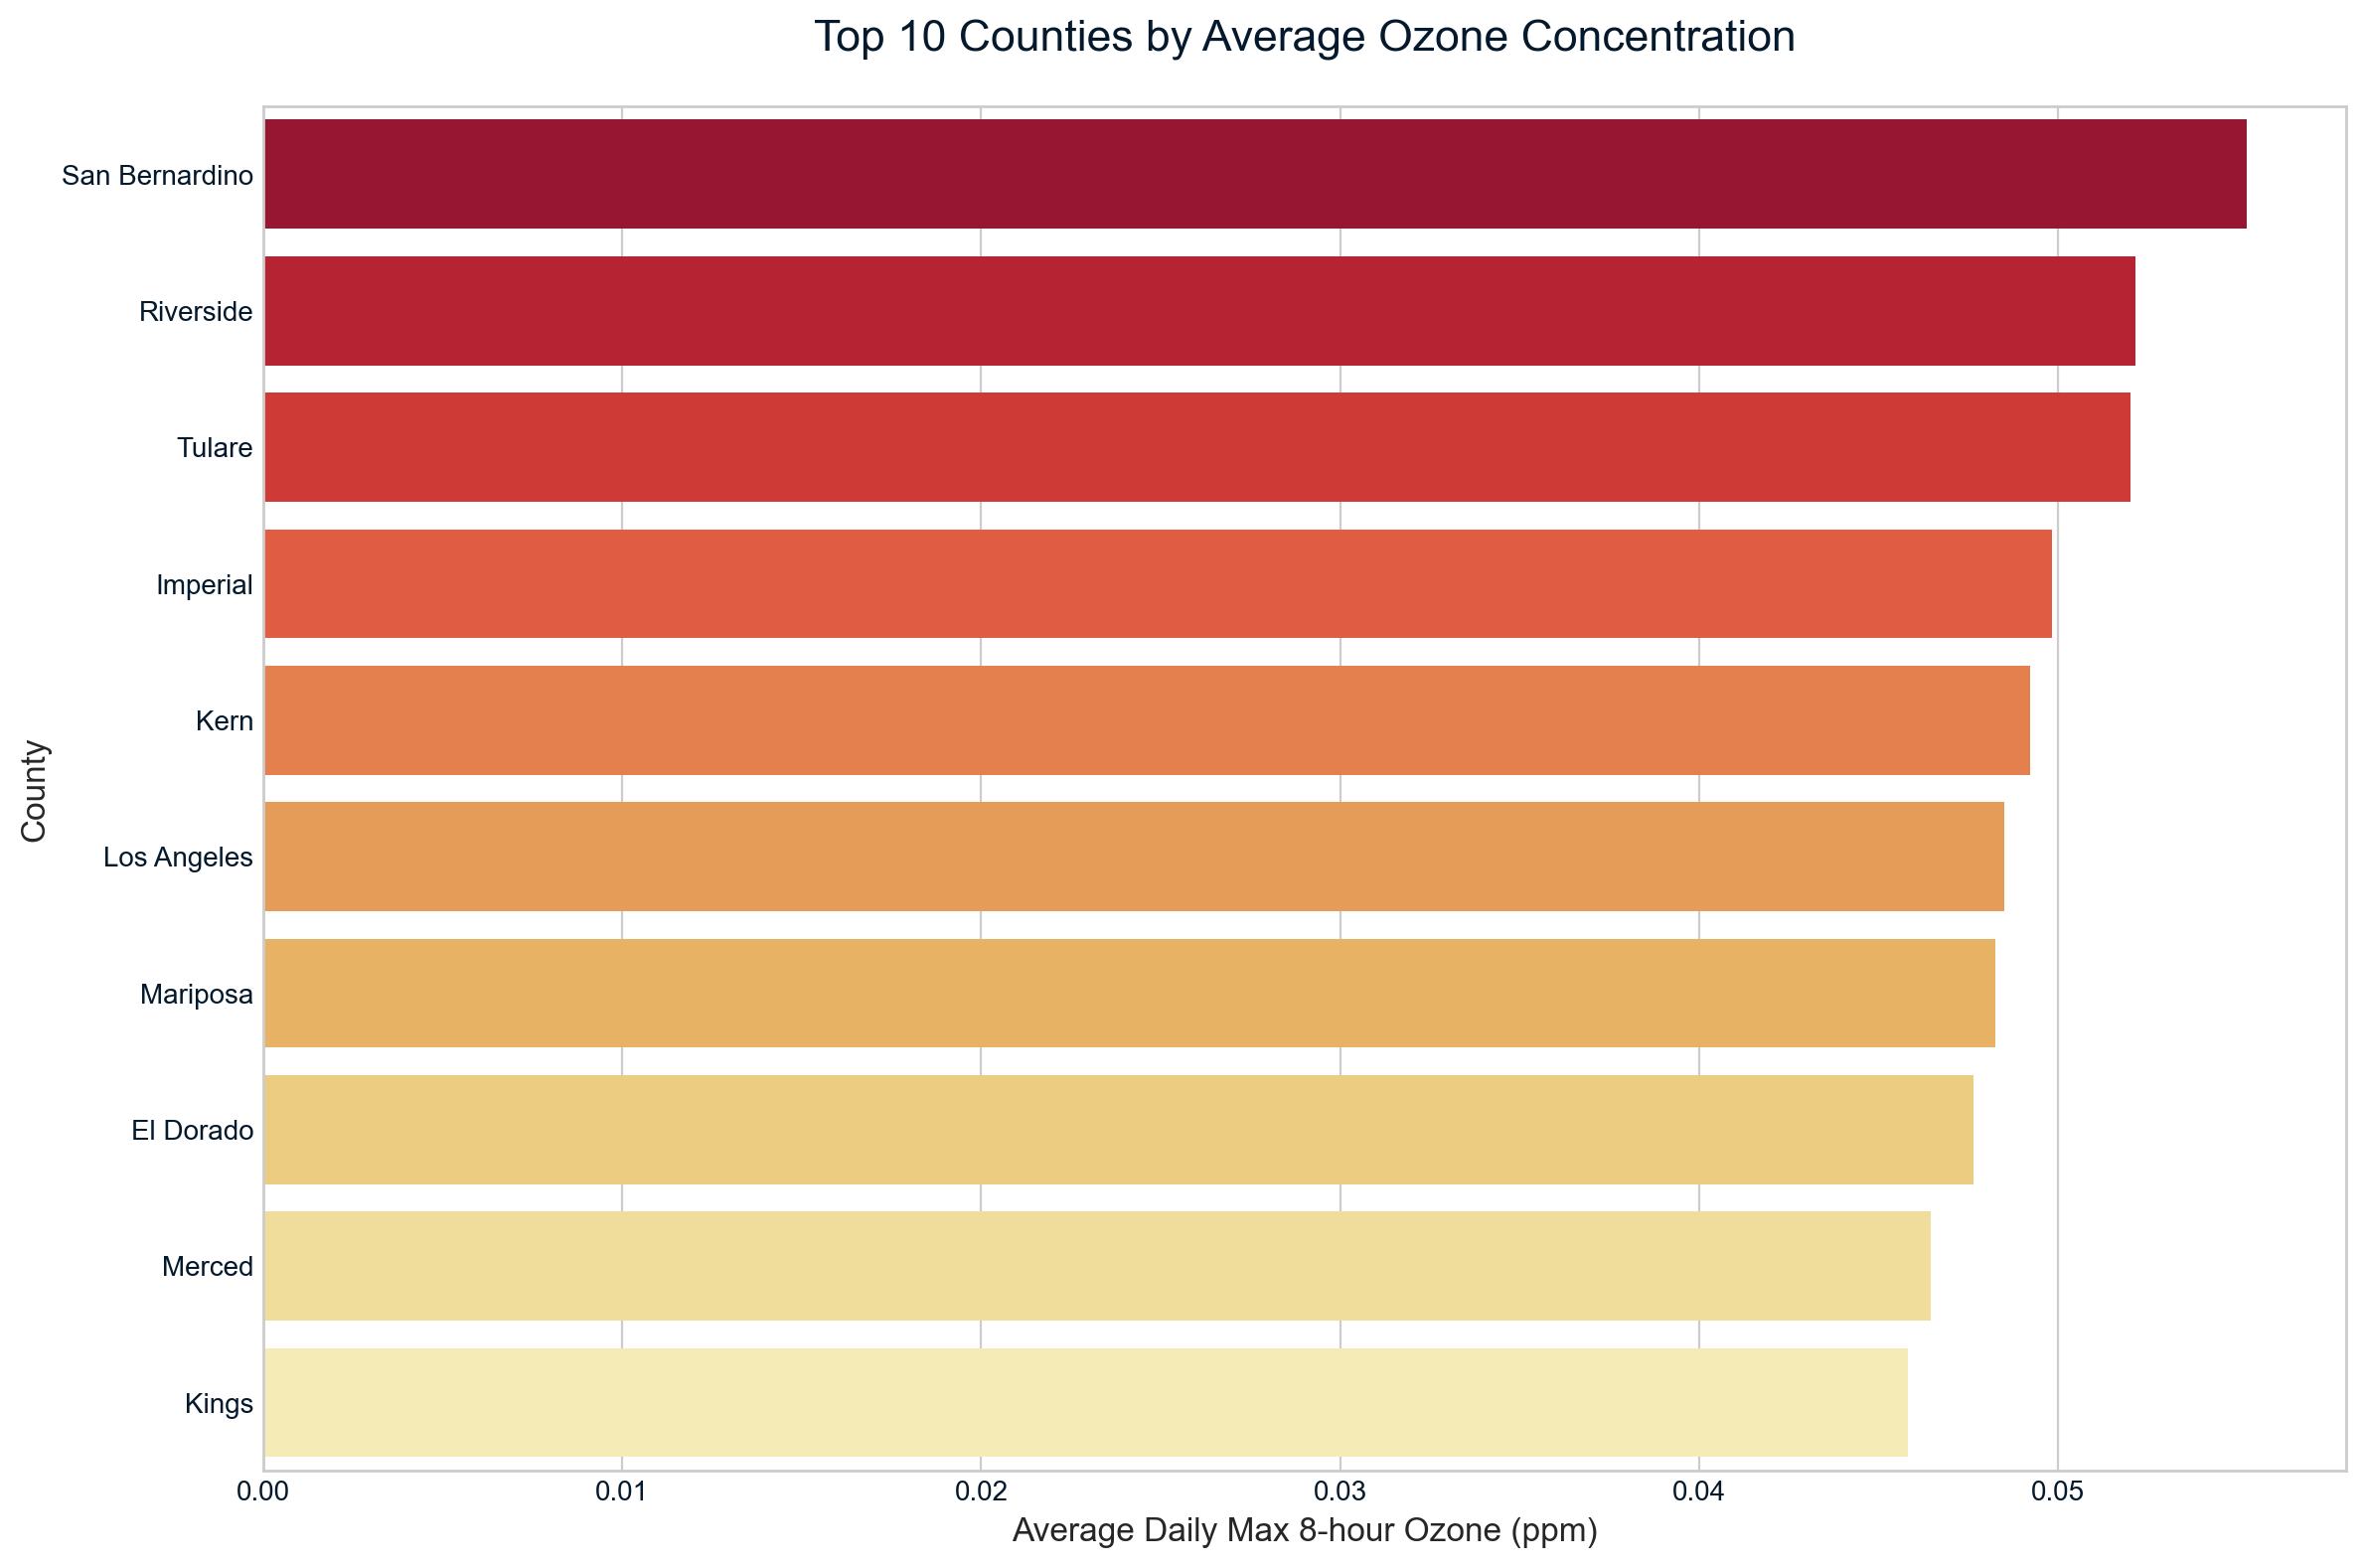

In [307]:
# --- Analyze by Region (County) ---
print("\\n--- Identifying Top 10 Counties with Highest Average Ozone ---")

# Define the column names from your notebook
ozone_col = 'Daily Max 8-hour Ozone Concentration'
county_col = 'County'

# Group by county, calculate the mean, and sort to find the highest
county_avg_ozone = df_analysis.groupby(county_col)[ozone_col].mean().sort_values(ascending=False)

# Get the top 10 for visualization
top_10_counties = county_avg_ozone.head(10)

# --- Plotting ---
plt.figure(figsize=(12, 8))
# Use the reversed palette '_r' to make the highest values red
sns.barplot(x=top_10_counties.values, y=top_10_counties.index, palette='YlOrRd_r')

# --- Formatting ---
plt.title('Top 10 Counties by Average Ozone Concentration', fontsize=16, pad=20)
plt.xlabel('Average Daily Max 8-hour Ozone (ppm)', fontsize=12)
plt.ylabel('County', fontsize=12)

plt.tight_layout()
plt.show()

\n--- Plotting Monthly Ozone Trends for Top 5 Counties ---


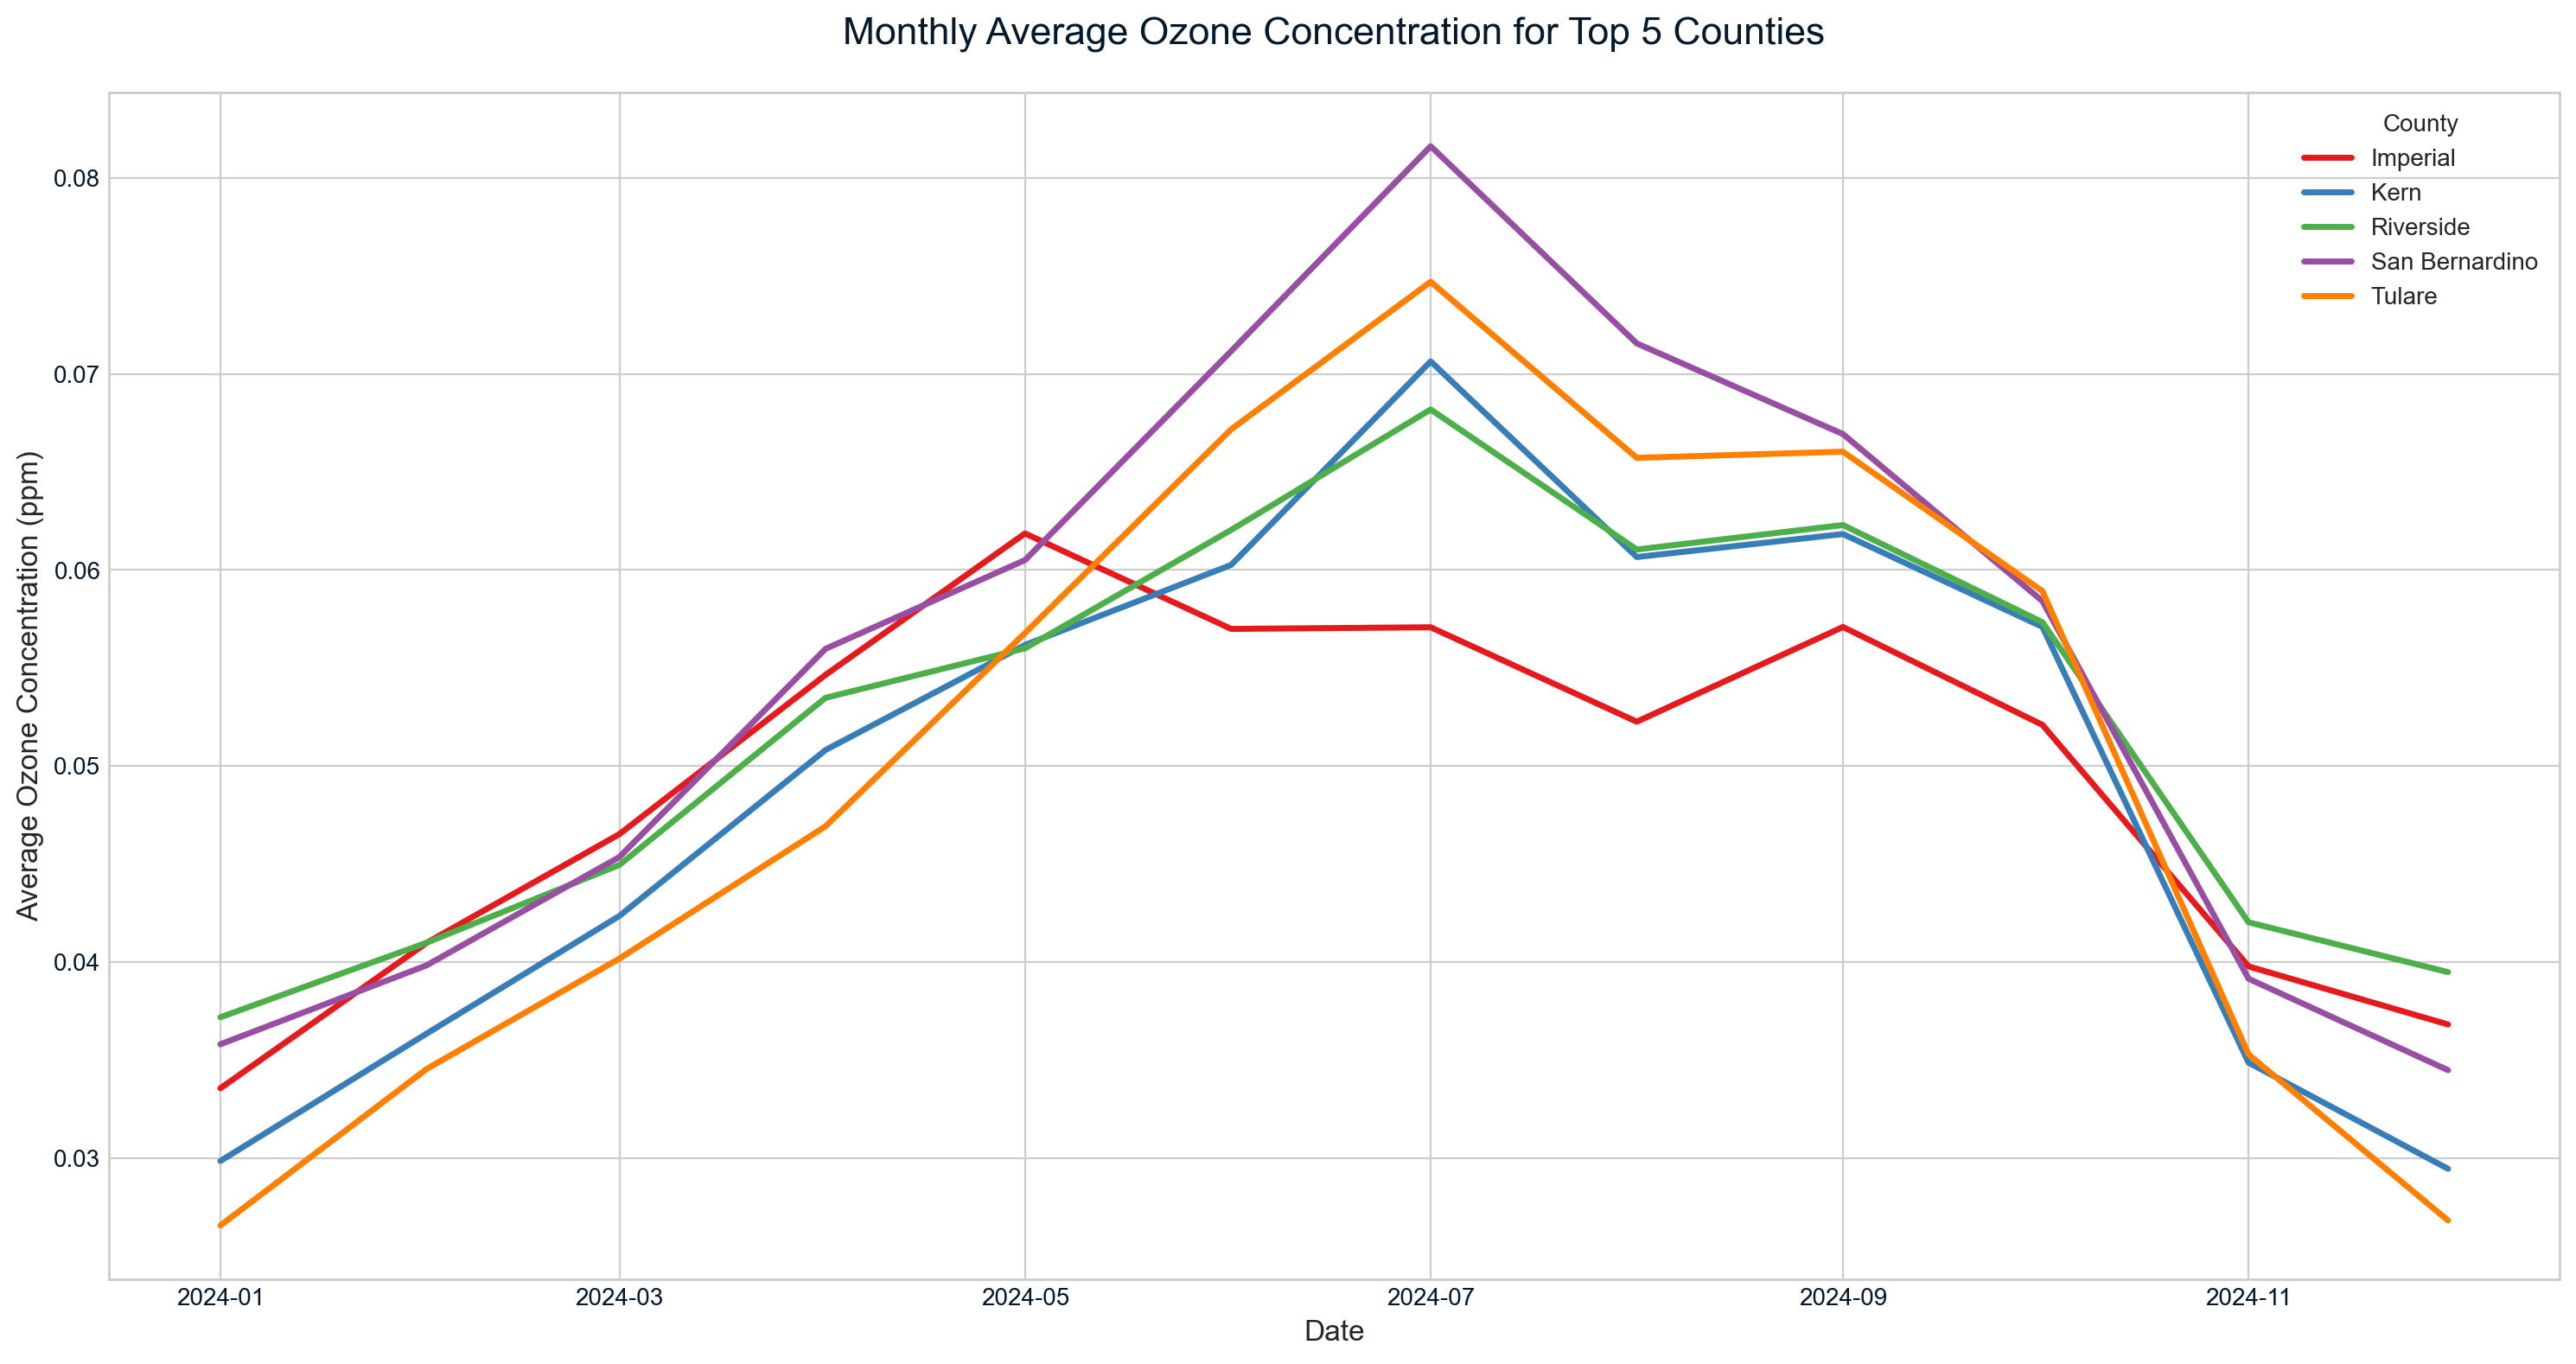

In [308]:
# --- Combined Analysis: Time and Region ---
print("\\n--- Plotting Monthly Ozone Trends for Top 5 Counties ---")

# Get the names of the top 5 counties from the previous cell's output
top_5_county_names = top_10_counties.head(5).index.tolist()

# Filter the DataFrame to include only data for these 5 counties
df_top5 = df_analysis[df_analysis['County'].isin(top_5_county_names)]

# --- FIX: Resample the data to get the monthly average for each county ---
# We group by county first, then resample each county's data to a monthly frequency ('MS' = Month Start)
df_monthly_avg = df_top5.groupby('County').resample('MS')['Daily Max 8-hour Ozone Concentration'].mean().reset_index()


# --- Plotting ---
plt.figure(figsize=(15, 8))

# Create a line plot using the NEW resampled monthly data
sns.lineplot(
    data=df_monthly_avg,
    x='Date',  # The index of the resampled data is now monthly
    y='Daily Max 8-hour Ozone Concentration',
    hue='County',  # Use 'County' to create separate colored lines
    palette='Set1',
    linewidth=2.5
)

# --- Formatting ---
plt.title('Monthly Average Ozone Concentration for Top 5 Counties', fontsize=16, pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Ozone Concentration (ppm)', fontsize=12)
plt.legend(title='County')

plt.tight_layout()
plt.show()

## Q2: Are there any areas that consistently show high ozone concentrations? Do different methods report different ozone levels?

--- Finding Counties with the Most High-Ozone Days ---
The plot below shows which counties most frequently have ozone levels in the top 10% for any given day.


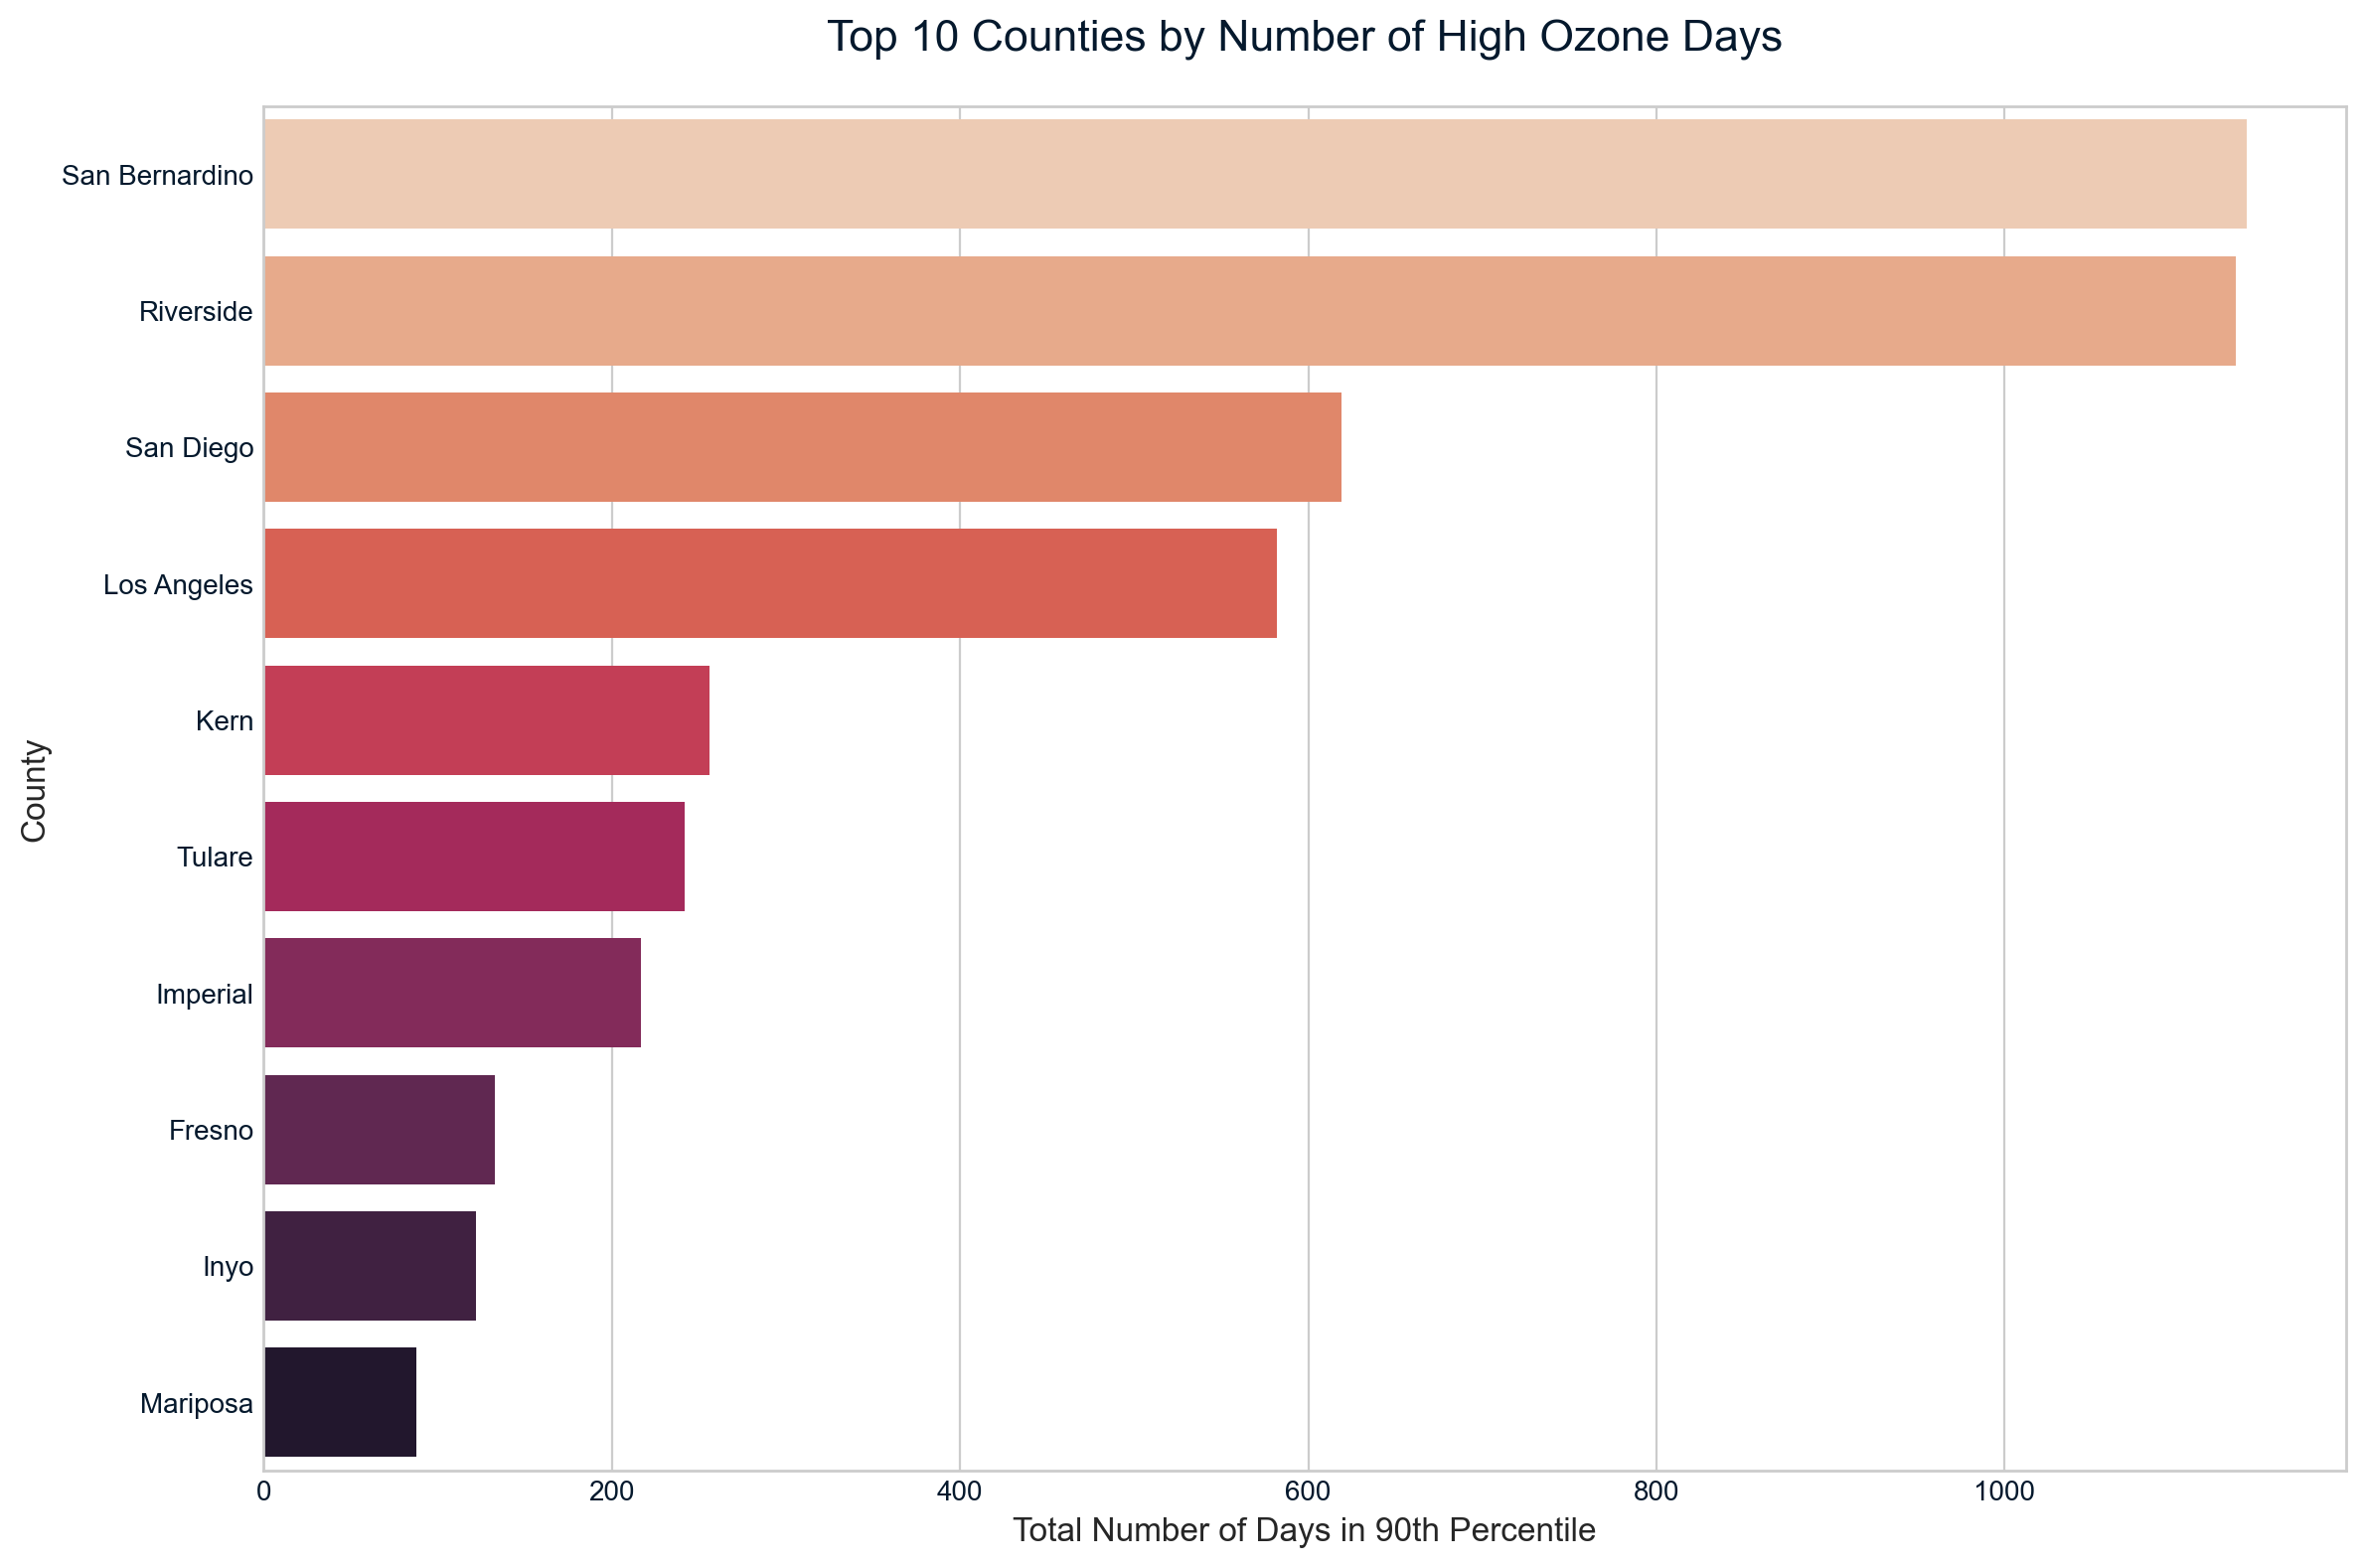

In [309]:
# --- Identify Consistently High-Ozone Counties ---
print("--- Finding Counties with the Most High-Ozone Days ---")

ozone_col = 'Daily Max 8-hour Ozone Concentration'
county_col = 'County'

# For each day, calculate the 90th percentile ozone value. This is our threshold for a "high" reading.
daily_high_ozone_threshold = df_analysis.groupby(df_analysis.index.date)[ozone_col].transform('quantile', 0.9)

# Create a boolean column that is True if the ozone reading is above that day's threshold
df_analysis['Is High Ozone Day'] = df_analysis[ozone_col] > daily_high_ozone_threshold

# Group by county and count the number of high ozone days
high_day_counts = df_analysis.groupby(county_col)['Is High Ozone Day'].sum().sort_values(ascending=False)

# Select the top 10 counties for visualization
top_10_consistent_counties = high_day_counts.head(10)

# --- Plotting ---
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_consistent_counties.values, y=top_10_consistent_counties.index, palette='rocket_r')

# --- Formatting ---
plt.title('Top 10 Counties by Number of High Ozone Days', fontsize=16, pad=20)
plt.xlabel('Total Number of Days in 90th Percentile', fontsize=12)
plt.ylabel('County', fontsize=12)

print("The plot below shows which counties most frequently have ozone levels in the top 10% for any given day.")
plt.tight_layout()
plt.show()

\n--- Comparing Ozone Distributions by Reporting Method ---
The box plot below shows the distribution of ozone readings for each method code.
Look for differences in the median (the line inside the box) and the spread (the height of the box).


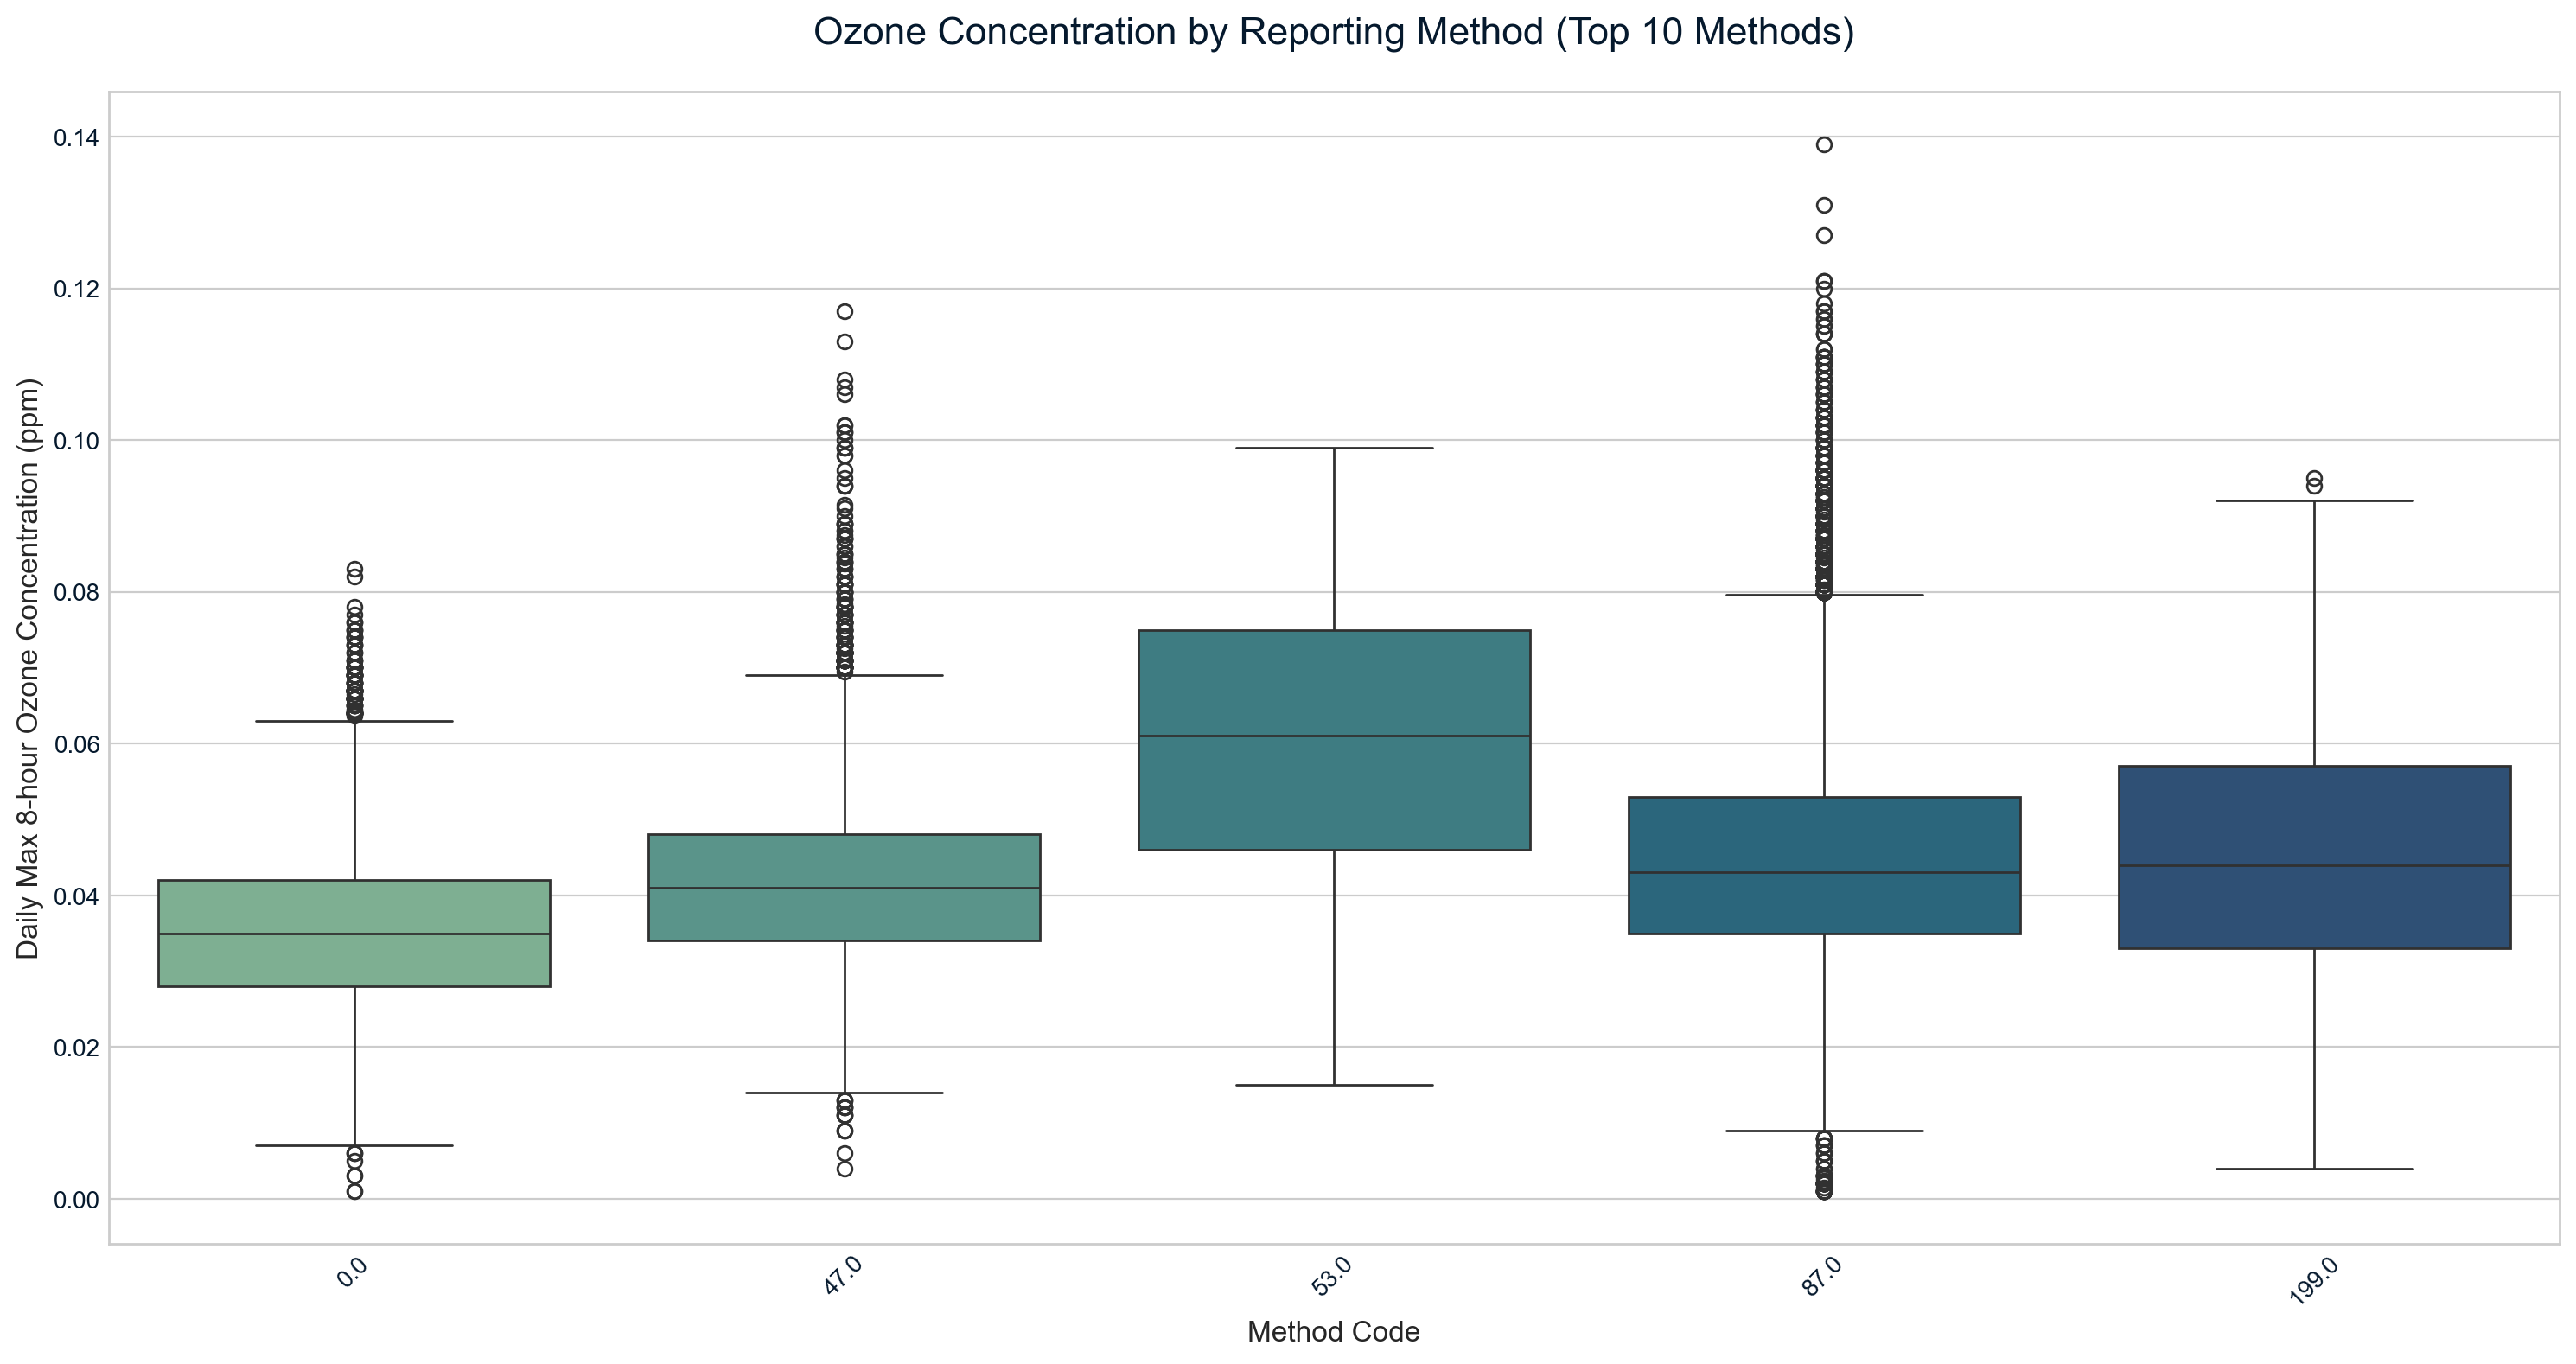

In [310]:
# --- Compare Ozone Levels by Method Code ---
print("\\n--- Comparing Ozone Distributions by Reporting Method ---")

method_col = 'Method Code'
ozone_col = 'Daily Max 8-hour Ozone Concentration'

# Find the most frequently used method codes to keep the plot readable
top_method_codes = df_analysis[method_col].value_counts().nlargest(10).index

# Filter the DataFrame to only include these top methods
df_top_methods = df_analysis[df_analysis[method_col].isin(top_method_codes)]

# --- Plotting ---
plt.figure(figsize=(15, 8))
# Change the palette to a cooler option like 'crest'
sns.boxplot(data=df_top_methods, x=method_col, y=ozone_col, palette='crest', order=sorted(top_method_codes))

# --- Formatting ---
plt.title('Ozone Concentration by Reporting Method (Top 10 Methods)', fontsize=16, pad=20)
plt.xlabel('Method Code', fontsize=12)
plt.ylabel('Daily Max 8-hour Ozone Concentration (ppm)', fontsize=12)
plt.xticks(rotation=45)

print("The box plot below shows the distribution of ozone readings for each method code.")
print("Look for differences in the median (the line inside the box) and the spread (the height of the box).")
plt.tight_layout()
plt.show()

## Q3: Consider if urban activity (weekend vs. weekday) has any affect on ozone levels across different days.

In [311]:
## Categorize days into weekdays
# --- Create a 'Day Type' column (Weekday vs. Weekend) ---

# The dayofweek attribute returns Monday=0, Tuesday=1, ..., Sunday=6.
# We'll classify Saturday (5) and Sunday (6) as 'Weekend'.
df_analysis['Day Type'] = df_analysis.index.dayofweek.map(lambda x: 'Weekend' if x >= 5 else 'Weekday')

print("--- Created 'Day Type' column ---")
# Display the first 5 rows with the new column to verify
print(df_analysis[['Day Type']].head(7))

--- Created 'Day Type' column ---
           Day Type
Date               
2024-01-01  Weekday
2024-01-02  Weekday
2024-01-03  Weekday
2024-01-04  Weekday
2024-01-05  Weekday
2024-01-06  Weekend
2024-01-07  Weekend


The plot below shows if there is a general difference in ozone levels between weekdays and weekends.


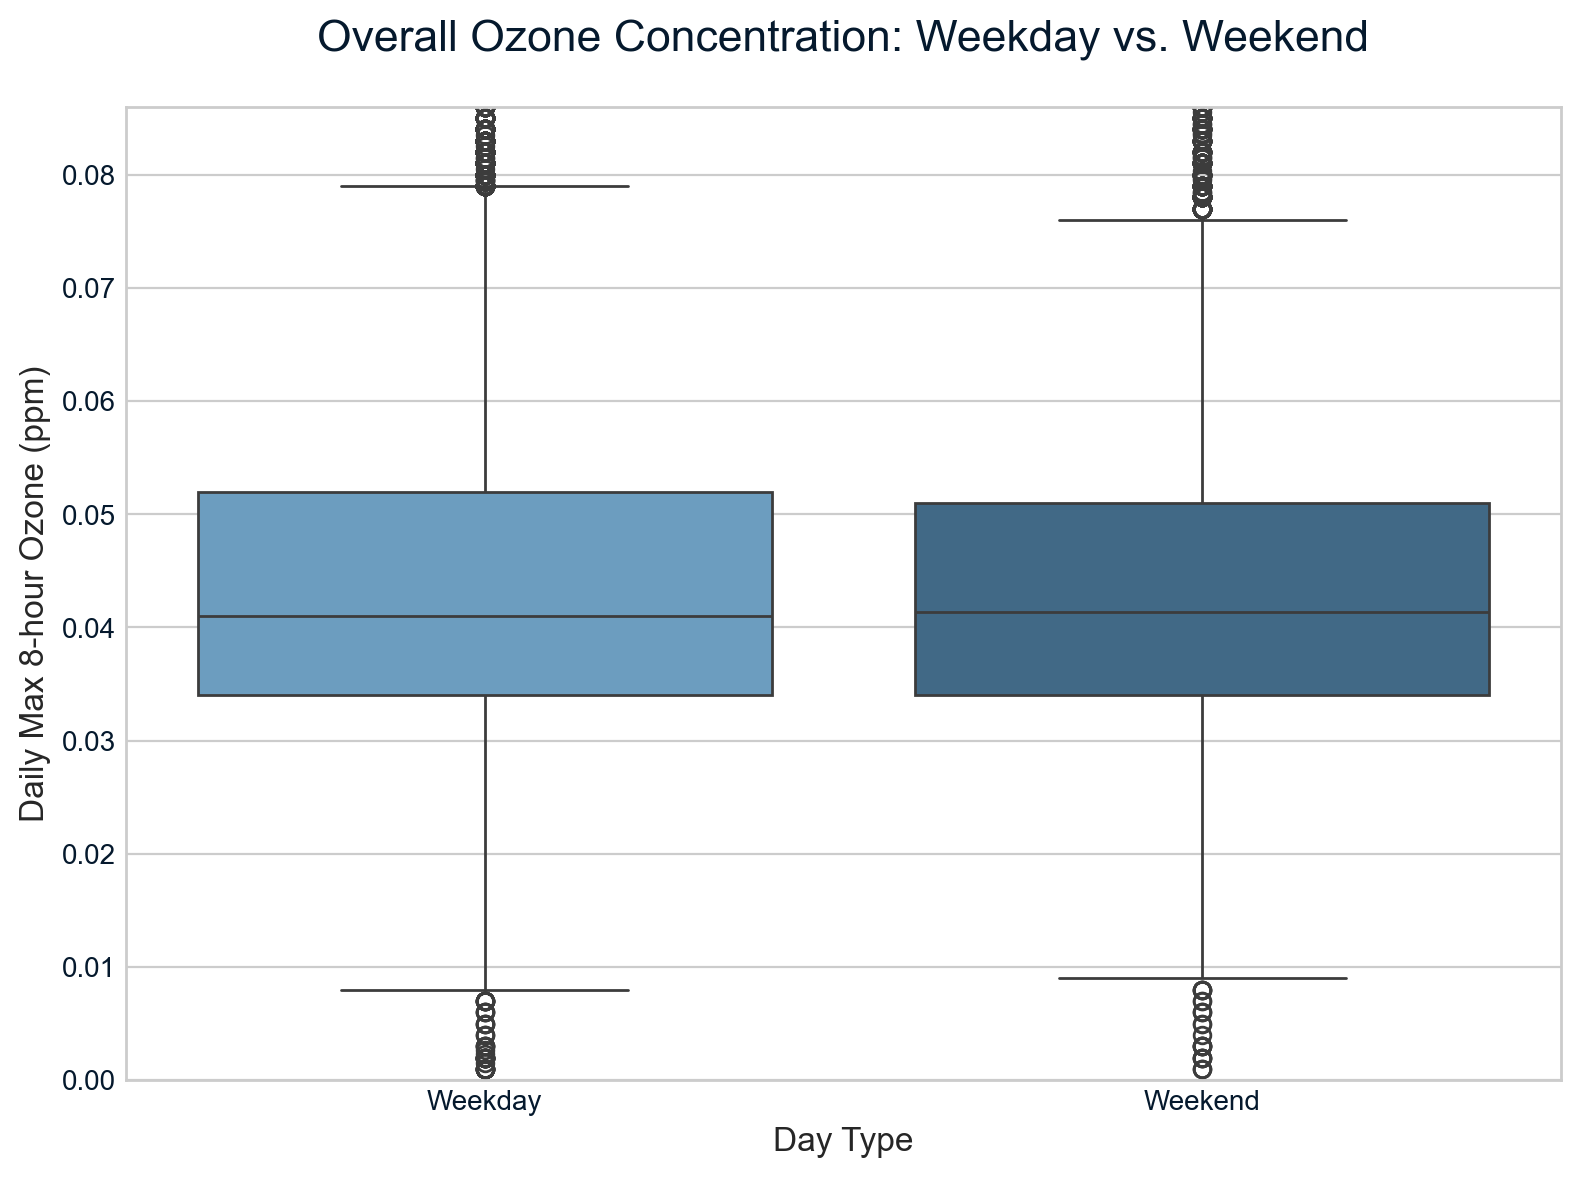

In [312]:
# --- Compare Overall Ozone: Weekday vs. Weekend ---
#print("\n--- Comparing Overall Ozone Distributions ---")

# --- Plotting ---
plt.figure(figsize=(8, 6))
# Using 'Blues_d' to match the color theme of the previous graph
sns.boxplot(data=df_analysis, x='Day Type', y='Daily Max 8-hour Ozone Concentration', palette='Blues_d')

# --- Formatting ---
plt.title('Overall Ozone Concentration: Weekday vs. Weekend', fontsize=16, pad=20)
plt.xlabel('Day Type', fontsize=12)
plt.ylabel('Daily Max 8-hour Ozone (ppm)', fontsize=12)
# Set y-axis limit to better see the distribution, excluding extreme outliers
plt.ylim(0, df_analysis['Daily Max 8-hour Ozone Concentration'].quantile(0.99))


print("The plot below shows if there is a general difference in ozone levels between weekdays and weekends.")
plt.tight_layout()
plt.show()

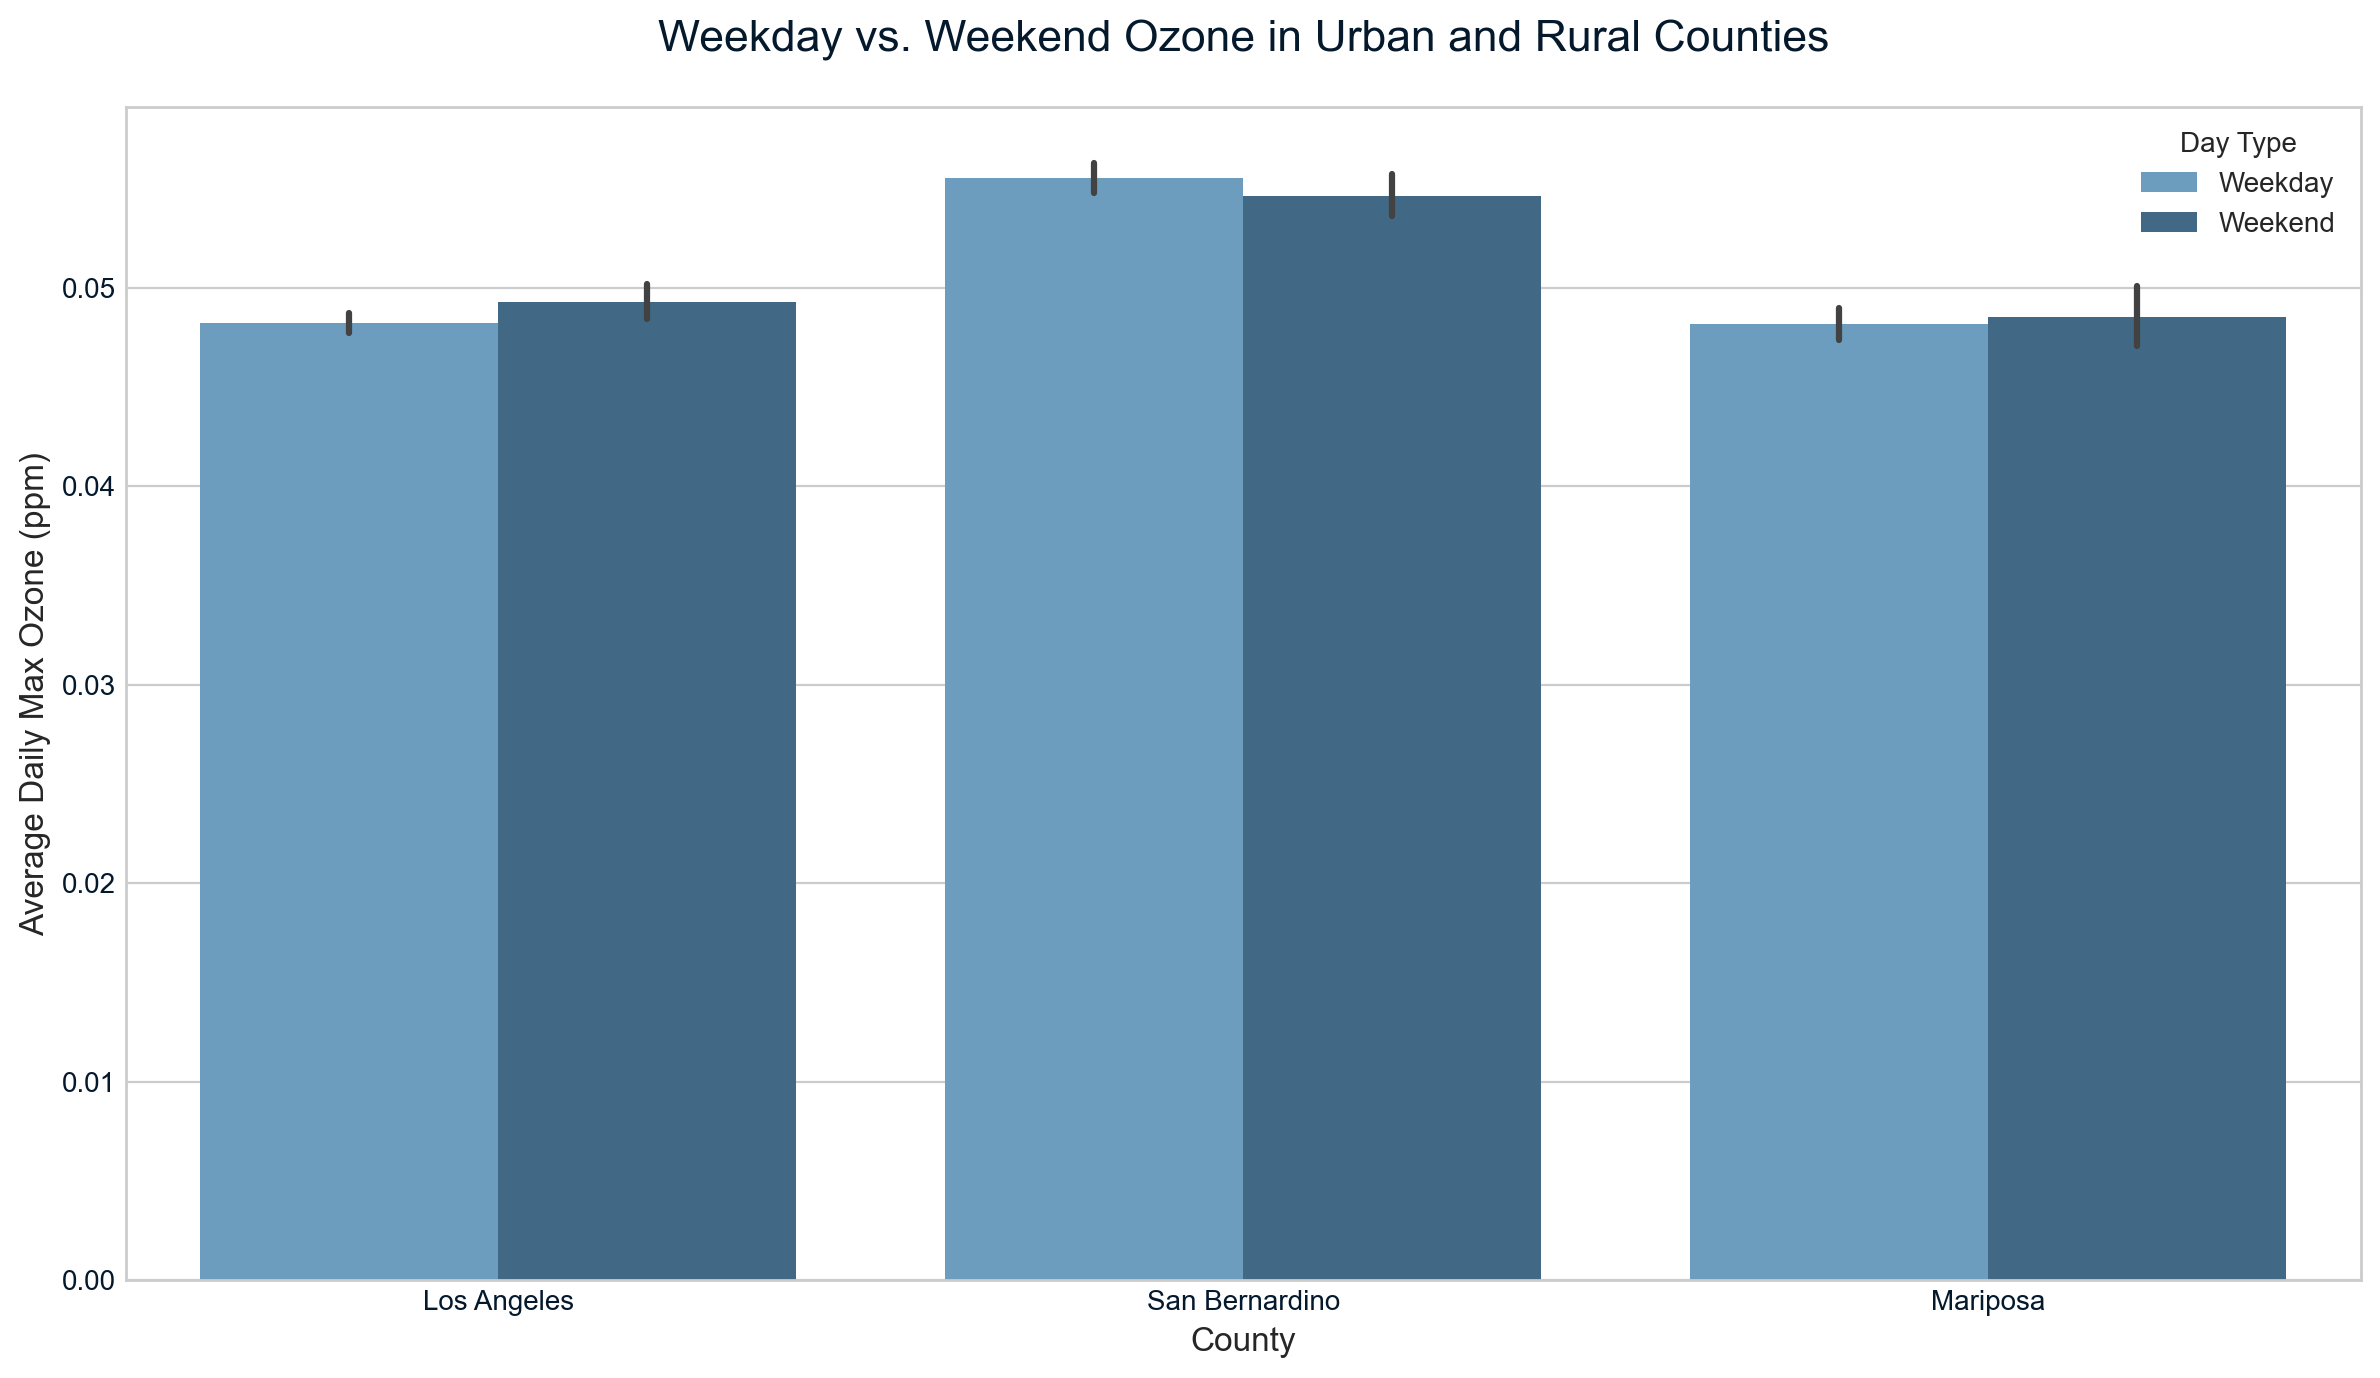

In [313]:
# --- Regional Comparison ---
#print("\\n--- Regional Comparison of the Weekend Effect ---")

# Select a few representative counties for comparison
counties_to_compare = ['Los Angeles', 'San Bernardino', 'Mariposa']
df_regional = df_analysis[df_analysis['County'].isin(counties_to_compare)]

# --- Plotting ---
plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_regional,
    x='County',
    y='Daily Max 8-hour Ozone Concentration',
    hue='Day Type',
    palette='Blues_d',
    order=counties_to_compare
)

# --- Formatting ---
plt.title('Weekday vs. Weekend Ozone in Urban and Rural Counties', fontsize=16, pad=20)
plt.xlabel('County', fontsize=12)
plt.ylabel('Average Daily Max Ozone (ppm)', fontsize=12)
plt.legend(title='Day Type')

plt.tight_layout()
plt.show()

## **Bonus: plot a geospatial heatmap showing any high ozone concentrations.**

Coastal areas show lower Ozone Pollution levels


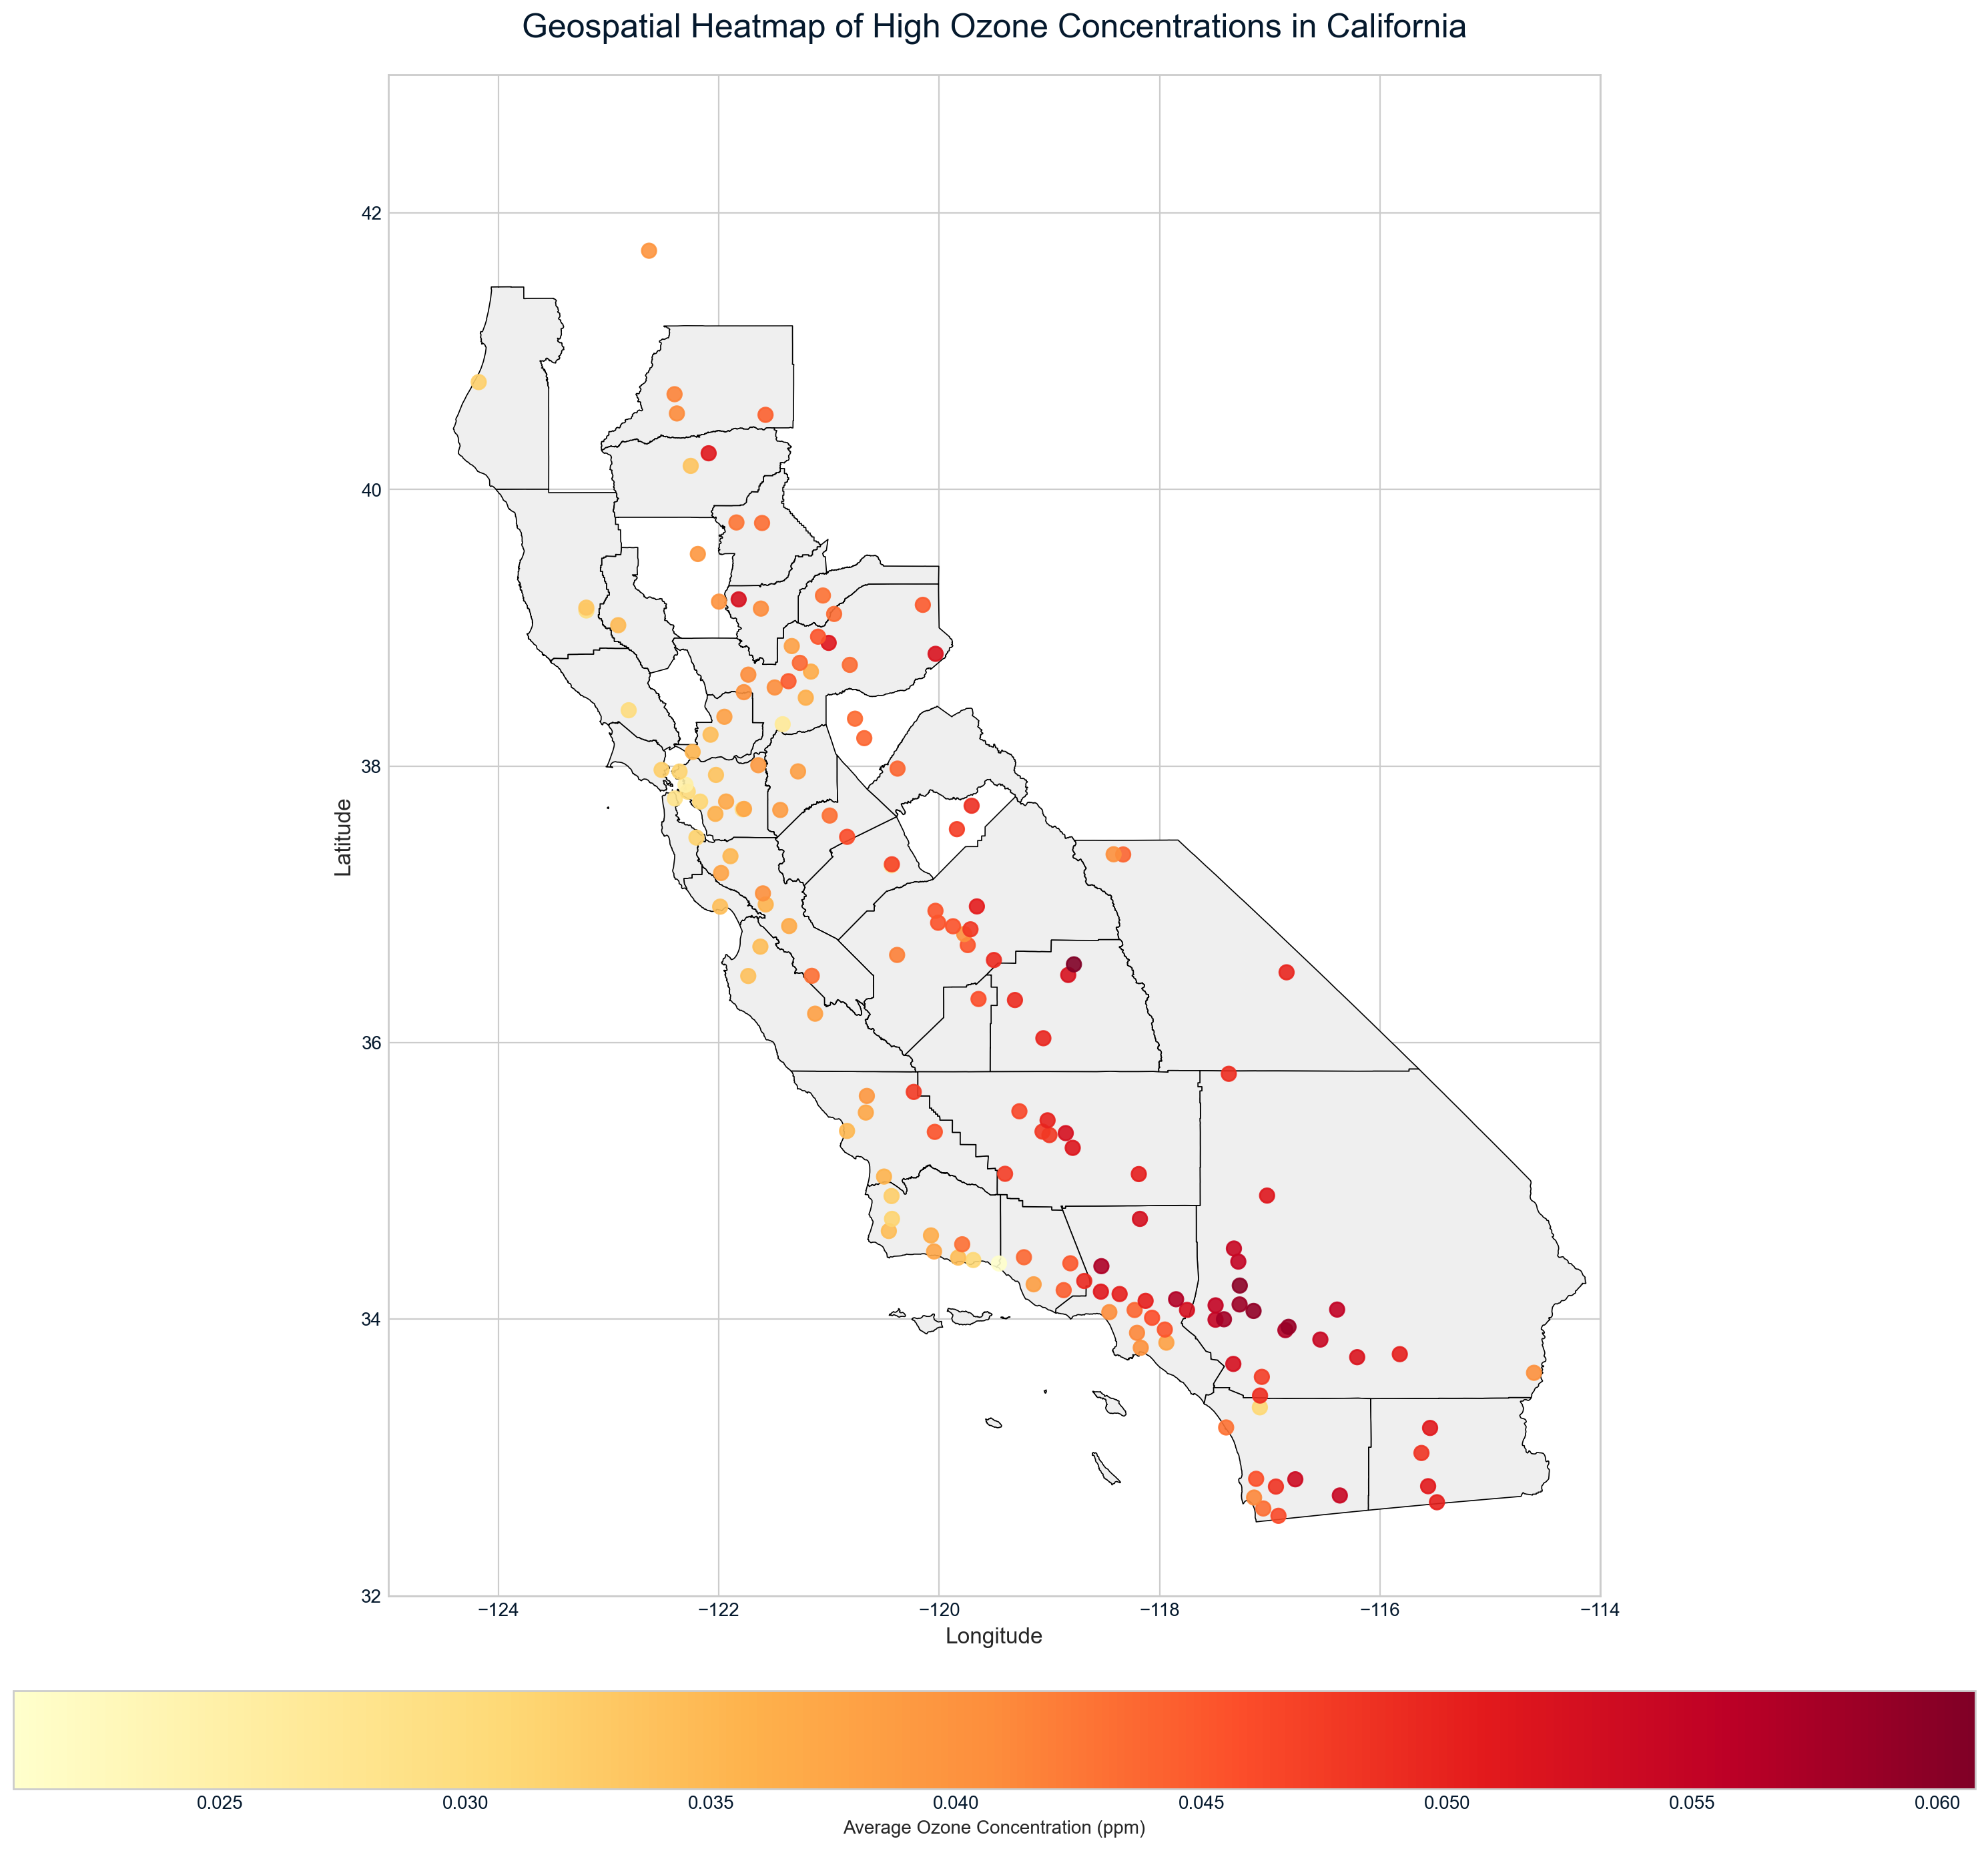

In [314]:
# You may need to install geopandas and pygeos first in your environment:
# !pip install geopandas pygeos

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# --- Step 1: Prepare your Ozone Data ---

# This DataFrame should already exist from previous steps.
# If not, run this line to create it:
site_avg_ozone = df_analysis.groupby(['Site Latitude', 'Site Longitude'])['Daily Max 8-hour Ozone Concentration'].mean().reset_index()

# Convert your ozone data into a GeoDataFrame
gdf_ozone_sites = gpd.GeoDataFrame(
    site_avg_ozone,
    geometry=gpd.points_from_xy(site_avg_ozone['Site Longitude'], site_avg_ozone['Site Latitude']),
    crs="EPSG:4326"  # Set standard latitude/longitude coordinate system
)


# --- Step 2: Load and Filter the US CBSA Map ---

# The filename from the zip file you downloaded
us_cbsa_map_path = 'cb_2023_us_cbsa_500k.shp'

try:
    # Load the map of all US Core Based Statistical Areas
    us_cbsa_map = gpd.read_file(us_cbsa_map_path)

    # Get the unique CBSA codes from your California ozone data
    # We need to convert them to strings to match the map's 'CBSAFP' column
    california_cbsa_codes = df_analysis['CBSA Code'].astype(int).astype(str).unique()

    # Filter the US map to include only the CBSAs present in your dataset
    california_cbsa_map = us_cbsa_map[us_cbsa_map['CBSAFP'].isin(california_cbsa_codes)]

    print(f"Coastal areas show lower Ozone Pollution levels")

except Exception as e:
    print(f"Could not load the shapefile. Please ensure 'cb_2023_us_cbsa_500k.shp' and its related files are uploaded.")
    print(f"Error: {e}")
    # Create an empty map as a fallback
    california_cbsa_map = gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")


# --- Step 3: Create the Plot ---

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Plot the filtered California CBSA boundaries as the base map
if not california_cbsa_map.empty:
    california_cbsa_map.plot(ax=ax, color='#EFEFEF', edgecolor='black', linewidth=0.6)

# Plot the ozone monitoring sites on top
# The color of each point is determined by its average ozone concentration
gdf_ozone_sites.plot(
    ax=ax,
    column='Daily Max 8-hour Ozone Concentration',
    cmap='YlOrRd', # Yellow-Orange-Red is great for heatmaps
    legend=True,
    legend_kwds={'label': "Average Ozone Concentration (ppm)", 'orientation': "horizontal", "pad": 0.05},
    markersize=60,
    alpha=0.9
)


# --- Step 4: Formatting and Final Touches ---

ax.set_title('Geospatial Heatmap of High Ozone Concentrations in California', fontsize=18, pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Set map limits to focus on California
ax.set_xlim(-125, -114)
ax.set_ylim(32, 43)

plt.tight_layout()
plt.show()